# Lung Cancer Incidence and Environmental Determinants in California MSSAs
## A Reproducible Analytical Pipeline

**Study design:** Area-level ecological analysis linking CalEnviroScreen 4.0
pollution and social-determinant-of-health (SDOH) indicators to California
Cancer Registry age-adjusted lung cancer incidence rates (AAIR) across
542 Medical Service Study Areas (MSSAs).

---

### Scope and Objectives

This notebook implements a complete, reproducible analytical pipeline for
investigating the association between environmental exposures,
socioeconomic factors, and lung cancer incidence at the sub-county level
in California. The analysis proceeds through five phases:

1. **Data assembly and quality assessment** — loading, cleaning, and
   documenting missingness in the merged CalEnviroScreen × Cancer Registry
   dataset (§1–4).
2. **Multicollinearity diagnostics and feature selection** — variance
   inflation factors, Spearman correlation analysis, and a five-method
   feature-selection comparison anchored by a permutation-importance
   autoencoder (§6–7).
3. **Binary classification** — eight classifiers evaluated via stratified
   cross-validation to discriminate high- from low-AAIR MSSAs, with
   SHAP-based interpretability (§8–9).
4. **Equity and fairness auditing** — race/ethnicity-stratified
   sub-cohort evaluation and algorithmic fairness metrics (§10–11).
5. **Regression, sensitivity, and domain analyses** — OLS regression,
   cutoff-sweep sensitivity, health-outcome exclusion sensitivity, and
   variable-domain comparisons (§12–15).

### Methodological Safeguards

| Concern | Mitigation |
|---------|------------|
| Data leakage | All scaling and feature selection are performed exclusively within training folds via `sklearn.pipeline.Pipeline` |
| Unit-of-analysis errors | Every analysis explicitly states the unit (MSSA) and the exact sample size *N*; OLS is restricted to `Sex='Both'` rows |
| Small-area rate instability | Population-weighted sensitivity analysis; MSSAs with population < 5 000 are flagged |
| Autoencoder reproducibility | Full architecture, optimizer, learning rate, regularisation, and random seeds are specified; bootstrap rank stability is assessed |
| Multiple testing | Benjamini–Hochberg FDR correction is applied to group comparison p-values |
| Causal language | All results use associative language ("associated with"); no causal claims are made from ecological data |

### Visualization Standards

All figures use the **Okabe–Ito colorblind-safe palette**, are rendered at
≥ 300 DPI, and use **Arial** fonts at ≥ 8 pt to meet journal accessibility
requirements.

### Ethical Statement

All data are publicly available, de-identified, and aggregated at the MSSA
level. No IRB review was required per 45 CFR 46.104(d)(4) (publicly
available data).

### Environment Setup

The cell below installs any required Python packages that are not already
present in the runtime environment. All packages are available via PyPI.
If you are running this notebook in a pre-configured environment (e.g., a
Docker container with a `requirements.txt`), you may skip this cell.

In [1]:
# ── Install required packages (skip if already installed) ────────────────
import subprocess, sys

REQUIRED_PACKAGES = [
    "xgboost",       # Gradient-boosted tree classifier
    "shap",          # SHapley Additive exPlanation values
    "lightgbm",      # Light gradient boosting (optional comparisons)
    "torch",         # PyTorch — autoencoder feature selection
    "optuna",        # Hyperparameter tuning framework
    "statsmodels",   # OLS regression with heteroscedasticity-robust SEs
    "seaborn",       # Statistical visualisation
    "tqdm",          # Progress bars for long-running loops
]

for pkg in REQUIRED_PACKAGES:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", pkg],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
    except Exception:
        print(f"  Warning: could not install {pkg}")

print("Package installation complete.")

Package installation complete.


### Library Imports and Global Configuration

This cell loads all libraries, sets the global random seed for
reproducibility, configures matplotlib for publication-quality figures,
and defines helper utilities used throughout the notebook. Software
versions are printed at the end to support reproducibility reporting.

In [2]:
# ══════════════════════════════════════════════════════════════════════════
# Library Imports and Global Configuration
# ══════════════════════════════════════════════════════════════════════════

import warnings, os, time, json, math, platform
warnings.filterwarnings("ignore")

# ── Core scientific stack ────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from typing import Tuple, Dict, List
from scipy import stats
from tqdm import tqdm

# ── Scikit-learn: modelling, evaluation, and preprocessing ───────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    RepeatedStratifiedKFold)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score, brier_score_loss, matthews_corrcoef)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
from sklearn.feature_selection import mutual_info_classif
from packaging import version
from sklearn import __version__ as skl_ver
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Optional accelerated libraries (graceful fallback) ───────────────────
try:
    import xgboost as xgb; HAS_XGB = True
except Exception: HAS_XGB = False
try:
    import shap; HAS_SHAP = True
except Exception: HAS_SHAP = False
try:
    import torch
    from torch import nn
    from torch.utils.data import TensorDataset, DataLoader
    HAS_TORCH = True
except Exception: HAS_TORCH = False

# ── Reproducibility: fix all random seeds ────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)
np.random.seed(SEED)
if HAS_TORCH:
    torch.manual_seed(SEED)

# ── Output directory for all generated tables and figures ────────────────
OUTDIR = "./publication_outputs"
os.makedirs(OUTDIR, exist_ok=True)
IMG_DPI = 300       # Minimum DPI for journal submission
IMG_FMT = "png"     # Change to "pdf" or "svg" if vector output is preferred

# ── Okabe–Ito colorblind-safe palette ────────────────────────────────────
# Reference: Okabe & Ito (2008), Color Universal Design
OI = {"orange": "#E69F00", "skyblue": "#56B4E9", "green": "#009E73",
      "yellow": "#F0E442", "blue": "#0072B2", "red": "#D55E00",
      "pink": "#CC79A7", "black": "#000000"}
OI_LIST = list(OI.values())

# ── Matplotlib global settings (publication defaults) ────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "figure.dpi": 150, "savefig.dpi": IMG_DPI,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.05,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.6, "lines.linewidth": 1.2,
    "pdf.fonttype": 42, "ps.fonttype": 42,   # Editable text in PDF/EPS
    "axes.prop_cycle": plt.cycler(color=OI_LIST),
})
sns.set_theme(style="ticks", context="paper", font_scale=1.0,
              rc={"axes.spines.top": False, "axes.spines.right": False})

# ── Human-readable variable labels for figures and tables ────────────────
NICE_NAMES = {
    "QNSES": "Neighborhood SES Quintile",
    "PerRural": "% Rural Population",
    "PerUninsured": "% Uninsured",
    "PerForeignBorn": "% Foreign-Born",
    "PerSmoking": "% Smoking",
    "CES_Ozone": "Ozone (ppm)",
    "CES_PM2.5": "PM\u2082.\u2085 (\u00b5g/m\u00b3)",
    "CES_Diesel_PM": "Diesel PM (\u00b5g/m\u00b3)",
    "CES_Drinking_Water": "Drinking Water Contaminants",
    "CES_Lead": "Lead Risk (% pre-1960 housing)",
    "CES_Pesticides": "Pesticide Use (kg/km\u00b2)",
    "CES_Tox._Release": "Toxic Releases (lb)",
    "CES_Traffic": "Traffic Density (AADT/km)",
    "CES_Cleanup_Sites": "Cleanup Sites (weighted count/km\u00b2)",
    "CES_Groundwater_Threats": "Groundwater Threats (weighted count/km\u00b2)",
    "CES_Haz._Waste": "Hazardous Waste Sites (weighted count/km\u00b2)",
    "CES_Imp._Water_Bodies": "Impaired Water Bodies",
    "CES_Solid_Waste": "Solid Waste Sites (weighted count/km\u00b2)",
    "CES_Pollution_Burden": "CES Pollution Burden Score",
    "CES_Asthma": "Asthma ED Visit Rate*",
    "CES_Low_Birth_Weight": "Low Birth Weight (%)*",
    "CES_Cardiovascular_Disease": "CVD Mortality Rate*",
    "CES_Education": "% No HS Diploma",
    "CES_Linguistic_Isolation": "% Linguistically Isolated",
    "CES_Poverty": "% Below 2\u00d7 FPL",
    "CES_Unemployment": "% Unemployed",
    "CES_Housing_Burden": "% Housing-Burdened",
    "MSSA_Area_SqMi": "MSSA Area (sq mi)",
    "PopDensity_sqmi_calc": "Population Density (per sq mi)",
}

# Health-outcome indicators that may constitute intermediate outcomes;
# these are tested in a sensitivity analysis (Section 12b) to ensure they
# do not drive classification results through outcome–predictor conflation.
HEALTH_OUTCOME_VARS = {"CES_Asthma", "CES_Low_Birth_Weight", "CES_Cardiovascular_Disease"}

def nice(col):
    """Return a human-readable label for a column name."""
    return NICE_NAMES.get(col, col)

def savefig(fig, name, **kw):
    """Save a figure to the output directory with standardised settings."""
    path = os.path.join(OUTDIR, f"{name}.{IMG_FMT}")
    fig.savefig(path, dpi=IMG_DPI, **kw)
    print(f"  Saved \u2192 {path}")

def plot_confusion_pct(y_true, y_pred, labels, title=None, save_name=None,
                       figsize=(3.3, 3.0), cmap="Blues"):
    """Plot a confusion matrix showing both percentages and raw counts."""
    cm_raw = confusion_matrix(y_true, y_pred)
    cm_pct = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True) * 100
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_pct, interpolation="nearest", cmap=cmap, vmin=0, vmax=100)
    for i in range(cm_pct.shape[0]):
        for j in range(cm_pct.shape[1]):
            color = "white" if cm_pct[i, j] > 50 else "black"
            ax.text(j, i, f"{cm_pct[i,j]:.1f}%\n(n={cm_raw[i,j]})",
                    ha="center", va="center", fontsize=9, fontweight="bold", color=color)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Observed")
    if title: ax.set_title(title, fontsize=10, pad=8, fontweight='bold')
    fig.tight_layout()
    if save_name: savefig(fig, save_name)
    plt.show()
    return cm_raw, cm_pct

# ── Print software versions for reproducibility reporting ────────────────
print("Software versions")
print(f"  Python:       {platform.python_version()}")
print(f"  NumPy:        {np.__version__}")
print(f"  pandas:       {pd.__version__}")
print(f"  scikit-learn: {skl_ver}")
print(f"  matplotlib:   {matplotlib.__version__}")
if HAS_TORCH: print(f"  PyTorch:      {torch.__version__}")
if HAS_XGB:   print(f"  XGBoost:      {xgb.__version__}")
if HAS_SHAP:  print(f"  SHAP:         {shap.__version__}")
print(f"  statsmodels:  {sm.__version__}")
print(f"  Random seed:  {SEED}")

Software versions
  Python:       3.12.11
  NumPy:        2.2.6
  pandas:       2.3.0
  scikit-learn: 1.7.0
  matplotlib:   3.10.3
  PyTorch:      2.11.0+cu130
  XGBoost:      3.2.0
  SHAP:         0.51.0
  statsmodels:  0.14.4
  Random seed:  42


---

## 1. Data Assembly and Cohort Definition

### 1a. Data Sources and Time Periods

Three publicly available datasets are merged for this analysis:

- **Cancer data —** Age-adjusted lung cancer incidence rates (AAIR, per
  100 000 person-years), standardised to the **2000 US Standard Population**,
  obtained from the **California Health Maps** portal
  ([californiahealthmaps.com](https://californiahealthmaps.com)), which
  draws on the California Cancer Registry.
  *Time period:* **2015–2019** (5-year aggregate).

- **Environmental and socioeconomic data —** **CalEnviroScreen 4.0**
  (OEHHA, released October 2021). Indicator reference periods vary by
  variable (typically 2017–2019 for pollution indicators and 2015–2019
  American Community Survey estimates for socioeconomic indicators).

- **Behavioral data —** **Adult Smoking Prevalence from CDC PLACES Project**
    (percent of adults aged 18 years and older who have smoked ≥100 cigarettes
    in their lifetime and currently smoke every day or some days), downloaded
    from the UCSF Health Atlas (healthatlas.ucsf.edu), which curates neighborhood-level
    measures from the CDC PLACES Project. PLACES provides model-based small-area
    estimates derived from BRFSS and American Community Survey data, available at
    the census tract level. Time period: 2020
    

### 1b. Geographic Unit and Aggregation

The unit of analysis throughout is the **Medical Service Study Area
(MSSA)**; there are **542 MSSAs** statewide. CalEnviroScreen indicators,
originally reported at the census-tract level, were aggregated to MSSAs
using **population-weighted means** (continuous indicators) or
**population-weighted sums** (count-based indicators) by the data
provider. The merged file is provided as
`healthmaps_with_ces4_pollution_plus_area.csv`.

### 1c. Inclusion and Exclusion Criteria

| Rule | Action |
|------|--------|
| Filter by sex | Retain rows where `Sex == 'Both'` to obtain MSSA-level overall AAIR (*N* = 542 MSSAs) |
| Suppressed race-specific rates | Rates are suppressed (NaN) when numerator < 5 or denominator < 500 for confidentiality; these MSSAs are excluded from race-specific analyses on a per-race basis |
| Missing overall AAIR | 21 of 542 MSSAs have missing overall AAIR and are excluded from analyses that require AAIR as the outcome |

## 2. Data Loading, Cleaning, and Missing-Data Summary

The cell below reads the merged CSV, filters to the MSSA-level cohort
(`Sex = 'Both'`), computes population density, and drops columns that
are not used as predictors (e.g., race-specific rates, screening
variables, and geographic identifiers). Race-specific rates are preserved
in a separate DataFrame for stratified analyses later.

> **Note:** Update the `CSV_PATH` variable below to point to the location
> of your copy of the merged dataset.

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# DATA LOADING
# Update CSV_PATH to the location of the merged dataset on your system.
# ══════════════════════════════════════════════════════════════════════════
CSV_PATH = "./data/healthmaps_with_ces4_pollution_plus_area.csv"

df_raw = pd.read_csv(CSV_PATH)
print(f"Full CSV: {df_raw.shape[0]} rows \u00d7 {df_raw.shape[1]} columns")

# ── Restrict to MSSA-level overall rates (Sex = 'Both') ─────────────────
df_mssa = df_raw[df_raw['Sex'] == 'Both'].copy().reset_index(drop=True)
N_MSSA = len(df_mssa)
print(f"MSSAs after Sex='Both' filter: N = {N_MSSA}")

# ── Preserve race-specific AAIRs for stratified analyses (Section 10) ───
race_cols = ["White_AAIR", "Black_AAIR", "Hispanic_AAIR", "Asian_AAIR"]
race_pop_cols = ["White_PopTot", "Black_PopTot", "Hispanic_PopTot", "Asian_PopTot"]
id_col = "MSSA_ID" if "MSSA_ID" in df_mssa.columns else None
meta_keep = [c for c in [id_col] + race_cols + race_pop_cols +
             ["PerWhite", "PerBlack", "PerAsian", "PerHispanic", "PopTot"]
             if c and c in df_mssa.columns]
race_df = df_mssa[meta_keep].copy()

# ── Derive population density (persons per square mile) ─────────────────
df = df_mssa.copy()
if {"PopTot", "MSSA_Shape__Area"}.issubset(df.columns):
    df["PopDensity_sqmi_calc"] = (
        df["PopTot"].to_numpy() / df["MSSA_Shape__Area"].to_numpy() * 2_589_988.11)

# ── Drop columns that are NOT used as predictors ────────────────────────
# These include race-specific sub-columns (used separately), screening
# variables, geographic identifiers, and redundant area/population fields.
drop_cols = [
    "White_PopTot", "White_AAIR", "White_LCI", "White_UCI",
    "Black_PopTot", "Black_AAIR", "Black_LCI", "Black_UCI",
    "Hispanic_PopTot", "Hispanic_AAIR", "Hispanic_LCI", "Hispanic_UCI",
    "Asian_PopTot", "Asian_AAIR", "Asian_LCI", "Asian_UCI",
    "PerWhite", "PerBlack", "PerAsian", "PerHispanic",
    "PerDocVisit", "PerFOBT", "PerMammo", "PerMenPrev",
    "PerCervical", "PerWomenPrev", "Years",
    "UCI", "LCI", "MSSA_NAME", "MSSA_ID", "AreaID_key",
    "PopAll", "PopDensity_sqmi", "MSSA_Shape__Area",
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
df = df.loc[:, ~df.columns.str.contains("_median", case=False, na=False)]

assert "AAIR" in df.columns, "Column 'AAIR' must exist."
N_AAIR = df['AAIR'].notna().sum()
print(f"Analysis data: {df.shape[0]} MSSAs \u00d7 {df.shape[1]} columns")
print(f"AAIR available: {N_AAIR} / {N_MSSA} MSSAs ({N_AAIR/N_MSSA*100:.1f}%)")

Full CSV: 1626 rows × 63 columns
MSSAs after Sex='Both' filter: N = 542
Analysis data: 542 MSSAs × 33 columns
AAIR available: 521 / 542 MSSAs (96.1%)


### 2a. Missing-Data Summary

Transparent reporting of missingness is essential for ecological studies
where suppression of small counts can introduce differential bias. The
table below reports per-variable availability across all 542 MSSAs.
The subsequent note summarises how missing data are handled in each
downstream analysis.

In [4]:
# ── Per-variable missing-data inventory ──────────────────────────────────
num_df = df.select_dtypes(include="number").copy()
miss_df = pd.DataFrame({
    "Variable": num_df.columns,
    "N_available": num_df.notna().sum().values,
    "N_missing": num_df.isna().sum().values,
    "Pct_missing": (num_df.isna().sum().values / len(num_df) * 100).round(1)
}).sort_values("Pct_missing", ascending=False)

print("Missing data by variable (predictors + outcome)")
print(miss_df.to_string(index=False))
miss_df.to_csv(os.path.join(OUTDIR, "missing_data_summary.csv"), index=False)

# ── Race-specific AAIR availability ──────────────────────────────────────
print("\nRace-specific AAIR availability (of N={} MSSAs):".format(N_MSSA))
for rc in race_cols:
    if rc in race_df.columns:
        n_avail = race_df[rc].notna().sum()
        print(f"  {rc:18s}: {n_avail:4d} ({n_avail/N_MSSA*100:.1f}%)")

# ── Document missing-data handling strategy per analysis ─────────────────
print("""
Missing-data handling by analysis:
  \u2022 Descriptive statistics:  per-variable complete cases
  \u2022 VIF / correlations:      listwise complete cases across numeric predictors
  \u2022 Autoencoder:             median imputation + StandardScaler (inside training fold)
  \u2022 Classification (8 models): median imputation + StandardScaler (inside training fold)
  \u2022 SHAP:                    same pipeline as classification (training-fold imputation)
  \u2022 OLS regression:          complete cases on selected variables (Sex='Both' MSSAs only)
  \u2022 Effect-size comparisons: complete cases per variable
  \u2022 Race-stratified models:  restricted to MSSAs with non-suppressed race-specific AAIR
""")

Missing data by variable (predictors + outcome)
                  Variable  N_available  N_missing  Pct_missing
                PerSmoking          519         23          4.2
                    PopTot          521         21          3.9
                      AAIR          521         21          3.9
      CES_Low_Birth_Weight          523         19          3.5
          CES_Unemployment          526         16          3.0
  CES_Linguistic_Isolation          537          5          0.9
               CES_Traffic          541          1          0.2
            MSSA_Area_SqMi          541          1          0.2
        CES_Housing_Burden          541          1          0.2
             CES_Education          541          1          0.2
            PerForeignBorn          542          0          0.0
                     QNSES          542          0          0.0
              PerUninsured          542          0          0.0
                  PerRural          542          0      

## 3. Descriptive Statistics (Table 1)

**Unit of analysis:** MSSA (*N* = 542).

Table 1 summarises the distribution of all numeric predictor variables
across MSSAs, including the count, percentage missing, mean, standard
deviation, quartiles, IQR, and range. Variables marked with an asterisk
(*) are health-outcome proxies whose inclusion as predictors is tested
in a sensitivity analysis (Section 12b).

In [5]:
pred_df = num_df.drop(columns=["AAIR", "PopTot"], errors="ignore")

desc = pred_df.describe(percentiles=[0.25, 0.50, 0.75]).T
desc["missing_%"] = (pred_df.isnull().sum() / len(pred_df) * 100).round(1)
desc["IQR"] = desc["75%"] - desc["25%"]
desc = desc[["count", "missing_%", "mean", "std", "25%", "50%", "75%", "IQR", "min", "max"]]
desc.columns = ["N", "Missing%", "Mean", "SD", "Q1", "Median", "Q3", "IQR", "Min", "Max"]
desc = desc.round(3)
desc.index = [nice(c) for c in desc.index]

print(f"Table 1: Descriptive Statistics (N = {N_MSSA} MSSAs)")
print(desc.to_string())
desc.to_csv(os.path.join(OUTDIR, "table1_descriptive_stats.csv"))
print(f"\n* Variables marked with * are health-outcome proxies (sensitivity analysis below)")

Table 1: Descriptive Statistics (N = 542 MSSAs)
                                                N  Missing%      Mean        SD       Q1   Median        Q3      IQR     Min        Max
Neighborhood SES Quintile                   542.0       0.0     3.000     1.414    2.000    3.000     4.000    2.000   1.000      5.000
% Rural Population                          542.0       0.0    22.824    34.065    0.000    2.800    34.075   34.075   0.000    100.000
% Uninsured                                 542.0       0.0     7.409     3.750    4.700    6.550     9.200    4.500   0.100     25.100
% Foreign-Born                              542.0       0.0    22.177    12.498   12.525   20.750    30.400   17.875   0.600     58.500
Ozone (ppm)                                 542.0       0.0     0.049     0.010    0.042    0.048     0.056    0.014   0.027      0.073
PM₂.₅ (µg/m³)                               542.0       0.0     9.145     2.604    7.440    8.818    11.677    4.237   2.227     15.844


## Figure 1 — Distribution of AAIR Across MSSAs

The histogram below shows the distribution of age-adjusted lung cancer
incidence rates across MSSAs. A Gaussian kernel density estimate (KDE) is
overlaid for visual smoothing. Vertical dashed lines mark the 40th and 60th
percentile thresholds that define the "Low" and "High" groups used in
the binary classification analysis (Section 8). MSSAs falling between these
thresholds constitute a **buffer zone** excluded from classification to
reduce label noise near the decision boundary.

  Saved → ./publication_outputs/fig1_AAIR_distribution.png


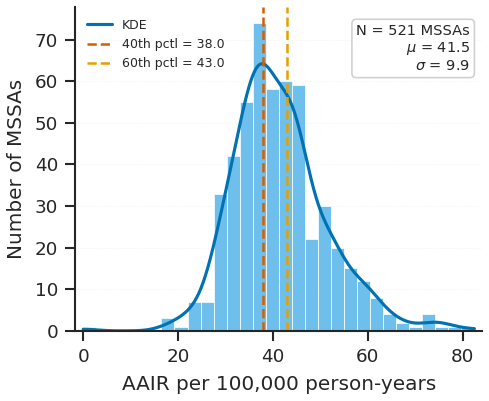

In [6]:
x = pd.to_numeric(df["AAIR"], errors="coerce").dropna().values
n = x.size
mu, med, sd = np.mean(x), np.median(x), np.std(x, ddof=1)
q45, q55 = np.percentile(x, [40, 60])

fig, ax = plt.subplots(figsize=(3.5, 2.8))
counts, bins, patches = ax.hist(
    x, bins="fd", color=OI["skyblue"], edgecolor="white", linewidth=0.4, alpha=0.85)

from scipy.stats import gaussian_kde
grid = np.linspace(bins[0], bins[-1], 512)
kde = gaussian_kde(x)
ax.plot(grid, kde(grid) * np.diff(bins).mean() * n,
        color=OI["blue"], linewidth=1.5, label="KDE")

ax.axvline(q45, color=OI["red"], linewidth=1.2, linestyle="--",
           label=f"40th pctl = {q45:.1f}")
ax.axvline(q55, color=OI["orange"], linewidth=1.2, linestyle="--",
           label=f"60th pctl = {q55:.1f}")

ax.set_xlabel("AAIR per 100,000 person-years")
ax.set_ylabel("Number of MSSAs")
ax.grid(axis="y", linestyle=":", alpha=0.3, linewidth=0.4)
ax.margins(x=0.02)

ax.text(0.97, 0.95,
        f"N = {n} MSSAs\n$\\mu$ = {mu:.1f}\n$\\sigma$ = {sd:.1f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=7,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", alpha=0.9))

ax.legend(frameon=False, fontsize=6, loc="upper left")
savefig(fig, "fig1_AAIR_distribution")
plt.show()


## 4. Small-Area Rate Instability Assessment

Age-adjusted rates computed from small populations can exhibit high
variance, potentially inflating apparent geographic disparities. To assess
this, we examine the relationship between MSSA total population and AAIR,
and flag MSSAs with fewer than 5 000 residents. The scatter plot uses a
logarithmic x-axis to accommodate the wide range of MSSA populations.

Later sensitivity analyses (Section 12c) incorporate population-weighted
classification to down-weight less precise rate estimates.

Rate instability assessment (N = 521 MSSAs with AAIR + PopTot)
  MSSAs with PopTot < 5,000: 0 (0.0%)
  Mean AAIR (small-area): nan
  Mean AAIR (larger):     41.5
  SD AAIR  (small-area):  nan
  SD AAIR  (larger):      9.9
  Saved → ./publication_outputs/fig_rate_instability.png


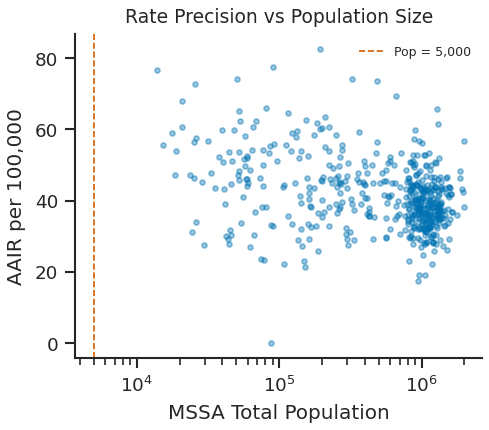

In [7]:
df_stab = df[["AAIR"]].copy()
df_stab["PopTot"] = df_mssa["PopTot"] if "PopTot" in df_mssa.columns else np.nan
df_stab = df_stab.dropna(subset=["AAIR", "PopTot"])
df_stab = df_stab[df_stab["PopTot"] > 0]

# Flag MSSAs with small populations (potential instability)
POP_THRESH = 5000  # flag MSSAs with total pop < 5000
df_stab["small_area"] = df_stab["PopTot"] < POP_THRESH
n_small = df_stab["small_area"].sum()
pct_small = n_small / len(df_stab) * 100

print(f"Rate instability assessment (N = {len(df_stab)} MSSAs with AAIR + PopTot)")
print(f"  MSSAs with PopTot < {POP_THRESH:,}: {n_small} ({pct_small:.1f}%)")
print(f"  Mean AAIR (small-area): {df_stab.loc[df_stab.small_area, 'AAIR'].mean():.1f}")
print(f"  Mean AAIR (larger):     {df_stab.loc[~df_stab.small_area, 'AAIR'].mean():.1f}")
print(f"  SD AAIR  (small-area):  {df_stab.loc[df_stab.small_area, 'AAIR'].std():.1f}")
print(f"  SD AAIR  (larger):      {df_stab.loc[~df_stab.small_area, 'AAIR'].std():.1f}")

# Scatter: population vs AAIR
fig, ax = plt.subplots(figsize=(3.5, 2.8))
ax.scatter(df_stab["PopTot"], df_stab["AAIR"], s=6, alpha=0.4, color=OI["blue"])
ax.axvline(POP_THRESH, color=OI["red"], linestyle="--", linewidth=0.8,
           label=f"Pop = {POP_THRESH:,}")
ax.set_xlabel("MSSA Total Population")
ax.set_ylabel("AAIR per 100,000")
ax.set_xscale("log")
ax.legend(frameon=False, fontsize=6)
ax.set_title("Rate Precision vs Population Size", fontsize=9)
savefig(fig, "fig_rate_instability")
plt.show()

## 5. Multicollinearity Diagnostics (VIF)

High multicollinearity among predictors can inflate coefficient variance in
regression and reduce the interpretability of feature-importance rankings.
We compute the **Variance Inflation Factor (VIF)** for each predictor after
standardisation (mean-zero, unit-variance). A VIF > 10 conventionally
signals problematic collinearity; VIF > 5 warrants caution.

*Note:* VIF is computed on listwise-complete cases across all numeric
predictors.

In [8]:
non_feat = ["Cancer", "AAIR", "AreaID", "Sex", "PopTot", "PopDensity_sqmi_calc"]
vif_df = df.drop(columns=[c for c in non_feat if c in df.columns], errors="ignore")
vif_df = vif_df.select_dtypes(include="number").dropna()

from sklearn.preprocessing import StandardScaler as _SS
vif_scaled = pd.DataFrame(_SS().fit_transform(vif_df), columns=vif_df.columns)

vif_results = pd.DataFrame({
    "Feature": [nice(c) for c in vif_scaled.columns],
    "Raw_name": vif_scaled.columns.tolist(),
    "VIF": [variance_inflation_factor(vif_scaled.values, i)
            for i in range(vif_scaled.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print(f"VIF Analysis (N = {len(vif_df)} complete-case MSSAs)")
print(vif_results[["Feature", "VIF"]].to_string(index=False))
print(f"\nFeatures with VIF > 10: {(vif_results['VIF'] > 10).sum()}")
print(f"Features with VIF > 5:  {(vif_results['VIF'] > 5).sum()}")
vif_results.to_csv(os.path.join(OUTDIR, "vif_analysis.csv"), index=False)

VIF Analysis (N = 495 complete-case MSSAs)
                                   Feature       VIF
                            % Below 2× FPL 14.331078
                CES Pollution Burden Score 12.767336
                 Neighborhood SES Quintile 10.694852
                           % No HS Diploma  8.780509
                 % Linguistically Isolated  7.152368
                            % Foreign-Born  7.037093
                                 % Smoking  6.290169
                             PM₂.₅ (µg/m³)  5.530141
            Lead Risk (% pre-1960 housing)  4.292729
                        % Housing-Burdened  3.654825
                               % Uninsured  3.364008
                 Traffic Density (AADT/km)  3.175480
                        % Rural Population  3.078911
                              % Unemployed  3.078893
               Drinking Water Contaminants  3.043002
                               Ozone (ppm)  3.003113
                       CVD Mortality Rate*  2.761587
   

## Figure 2 — Spearman Correlation Heatmap

Spearman rank correlations are used rather than Pearson because several
CalEnviroScreen indicators exhibit skewed distributions. The lower triangle
of the matrix is displayed; if more than 25 numeric predictors are present,
only the 25 with the highest variance are shown for readability.

  Saved → ./publication_outputs/fig2_correlation_heatmap.png


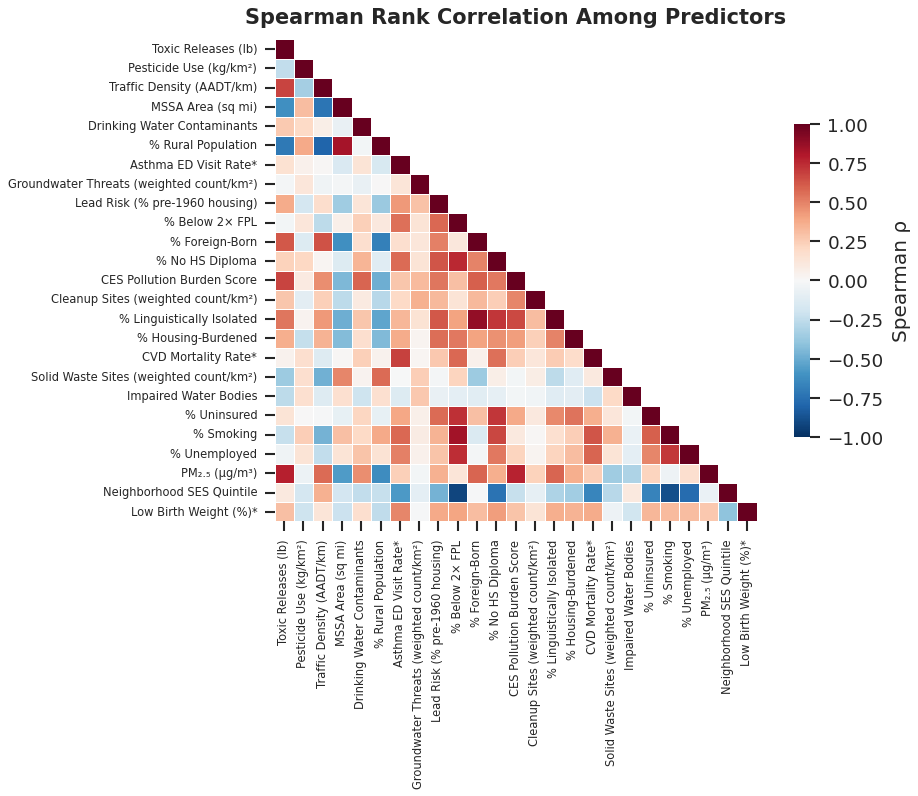

In [9]:
corr_non = ["Cancer", "AAIR", "AreaID", "Sex", "PopTot"]
corr_df = df.drop(columns=[c for c in corr_non if c in df.columns], errors="ignore")
corr_df = corr_df.select_dtypes(include="number")
if corr_df.shape[1] > 25:
    corr_df = corr_df[corr_df.var().nlargest(25).index.tolist()]

corr_df.columns = [nice(c) for c in corr_df.columns]
corr_mat = corr_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, mask=mask, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, annot=False,
            linewidths=0.3, linecolor="white", square=True,
            cbar_kws={"shrink": 0.65, "label": "Spearman ρ"}, ax=ax)
ax.tick_params(axis="both", labelsize=5.5)
ax.set_title("Spearman Rank Correlation Among Predictors", fontsize=10, pad=8, fontweight='bold')
fig.tight_layout()
savefig(fig, "fig2_correlation_heatmap")
plt.show()

## 6. Feature Selection — Nested, Leakage-Free Pipeline

Feature selection is performed using **five complementary methods** to
identify a robust set of predictors. The primary method is a
permutation-importance autoencoder; the remaining four (L1-penalised
logistic regression, mutual information, random-forest impurity
importance, and Spearman correlation pruning) serve as cross-validation
of the autoencoder's rankings.

### 6a. Autoencoder-Based Feature Importance

**Architecture and training details:**

| Component | Specification |
|-----------|---------------|
| Encoder | Input → 128 (ReLU, Dropout 0.1) → 64 (ReLU) → 16 (latent) |
| Decoder | 16 → 64 (ReLU) → 128 (ReLU) → Input |
| Optimiser | Adam (lr = 1 × 10⁻³, weight_decay = 1 × 10⁻⁵) |
| Training | 50 epochs, batch size = 64, no early stopping (fixed budget) |
| Importance metric | Permutation-based Δ reconstruction MSE (5 repeats per feature) |

**Key safeguard:** In the classification pipeline (Section 8), the
autoencoder and all scaling are re-fit exclusively on training folds to
prevent data leakage. The importance scores presented here are computed
on the full dataset for *descriptive purposes only*.

In [10]:
# ── Prepare feature matrix (MSSA-level, Sex='Both') ─────────────────────────
non_feature_cols = ["Cancer", "AAIR", "PopTot"]
feature_df = df.drop(columns=[c for c in non_feature_cols if c in df.columns]).copy()

num_cols = feature_df.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = [c for c in feature_df.columns if c not in num_cols]

SKL_NEW = version.parse(skl_ver) >= version.parse("1.2")
ohe_kw = {"handle_unknown": "ignore"}
ohe_kw["sparse_output" if SKL_NEW else "sparse"] = False

num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("scl", StandardScaler())])
ct = ColumnTransformer([("num", num_pipe, num_cols),
                         ("cat", OneHotEncoder(**ohe_kw), cat_cols)] if cat_cols
                        else [("num", num_pipe, num_cols)])

X_feat = ct.fit_transform(feature_df).astype(np.float32)
if hasattr(ct, "get_feature_names_out"):
    feature_names = list(ct.get_feature_names_out())
else:
    feature_names = num_cols + [f"cat_{i}" for i in range(X_feat.shape[1] - len(num_cols))]

print(f"Feature matrix: {X_feat.shape[0]} MSSAs × {X_feat.shape[1]} features")
print(f"  Numeric: {len(num_cols)}  |  Categorical (OHE): {X_feat.shape[1] - len(num_cols)}")

Feature matrix: 542 MSSAs × 571 features
  Numeric: 28  |  Categorical (OHE): 543


In [11]:
# -- Autoencoder (fully specified) ----------------------------------------
if not HAS_TORCH:
    raise RuntimeError("PyTorch required for autoencoder step.")

class AE(nn.Module):
    """Symmetric autoencoder: d_in -> 128 -> 64 -> d_latent -> 64 -> 128 -> d_in."""
    def __init__(self, d_in: int, d_latent: int = 16):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(d_in, 128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 64),   nn.ReLU(),
            nn.Linear(64, d_latent))
        self.dec = nn.Sequential(
            nn.Linear(d_latent, 64),  nn.ReLU(),
            nn.Linear(64, 128),       nn.ReLU(),
            nn.Linear(128, d_in))

    def forward(self, x):
        return self.dec(self.enc(x))

def train_autoencoder(X_np, seed=SEED, epochs=50, batch_size=64, lr=1e-3, wd=1e-5):
    """Train AE on given data; return trained model and baseline MSE."""
    torch.manual_seed(seed)
    d_in = X_np.shape[1]
    model = AE(d_in, d_latent=16)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    ds = TensorDataset(torch.from_numpy(X_np))
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for (batch,) in dl:
            recon = model(batch)
            loss = nn.functional.mse_loss(recon, batch)
            opt.zero_grad(); loss.backward(); opt.step()

    model.eval()
    with torch.no_grad():
        base_mse = float(nn.functional.mse_loss(
            model(torch.from_numpy(X_np)), torch.from_numpy(X_np)))
    return model, base_mse

def ae_permutation_importance(model, X_np, n_repeats=5, seed=SEED):
    """Permutation-based reconstruction importance."""
    rng_loc = np.random.default_rng(seed)
    with torch.no_grad():
        base = float(np.mean((model(torch.from_numpy(X_np)).numpy() - X_np)**2))
    deltas = []
    for j in range(X_np.shape[1]):
        incs = []
        for _ in range(n_repeats):
            Xp = X_np.copy()
            rng_loc.shuffle(Xp[:, j])
            with torch.no_grad():
                mse_p = float(np.mean((model(torch.from_numpy(Xp)).numpy() - Xp)**2))
            incs.append(mse_p - base)
        deltas.append(np.mean(incs))
    return np.array(deltas), base

# -- Map between prefixed and original column names --
prefixed_num_cols = [f"num__{c}" for c in num_cols if f"num__{c}" in feature_names]
clean_name_map = {f"num__{c}": c for c in num_cols if f"num__{c}" in feature_names}

# -- Train AE on FULL data for descriptive feature importance (Fig 3) --
ae_model, ae_base_mse = train_autoencoder(X_feat)
ae_deltas, _ = ae_permutation_importance(ae_model, X_feat)
print(f"AE training complete (50 epochs). Baseline MSE = {ae_base_mse:.6f}")

# Map back to original feature names (numeric only for interpretability)
ae_imp_df = pd.DataFrame({"feature": feature_names, "delta_mse": ae_deltas})
ae_imp_numeric = ae_imp_df[ae_imp_df["feature"].isin(prefixed_num_cols)].copy()
ae_imp_numeric = ae_imp_numeric.sort_values("delta_mse", ascending=False).reset_index(drop=True)
top15 = ae_imp_numeric.head(15)
print(f"\nTop 15 features by AE reconstruction importance:")
disp = top15.copy()
disp["feature_nice"] = disp["feature"].map(lambda f: nice(clean_name_map.get(f, f)))
print(disp[["feature_nice", "delta_mse"]].to_string(index=False))
top15.to_csv(os.path.join(OUTDIR, "ae_top15_features.csv"), index=False)


AE training complete (50 epochs). Baseline MSE = 0.011470

Top 15 features by AE reconstruction importance:
                  feature_nice  delta_mse
     Neighborhood SES Quintile   0.002814
                % Below 2× FPL   0.002644
               % No HS Diploma   0.002594
    CES Pollution Burden Score   0.002520
            % Rural Population   0.002493
                 PM₂.₅ (µg/m³)   0.002435
                     % Smoking   0.002399
     % Linguistically Isolated   0.002336
                % Foreign-Born   0.002297
     Traffic Density (AADT/km)   0.002084
Lead Risk (% pre-1960 housing)   0.001984
                   % Uninsured   0.001959
         Asthma ED Visit Rate*   0.001857
                  % Unemployed   0.001825
                   Ozone (ppm)   0.001781


### Bootstrap Rank Stability

To assess whether the autoencoder's feature rankings are stable across
resampled datasets, we run 50 bootstrap iterations. For each iteration,
the autoencoder is retrained on a bootstrap sample and permutation
importance is recomputed. The median rank and interquartile range (IQR)
of each feature across bootstraps are reported. Features with low median
rank and narrow IQR are considered robustly important.

In [12]:
# -- Bootstrap rank stability for AE feature selection --
N_BOOT_AE = 50
boot_ranks = {f: [] for f in prefixed_num_cols}

print(f"Bootstrap AE rank stability ({N_BOOT_AE} resamples)...")
for b in tqdm(range(N_BOOT_AE)):
    idx = rng.choice(X_feat.shape[0], X_feat.shape[0], replace=True)
    X_b = X_feat[idx]
    ae_b, _ = train_autoencoder(X_b, seed=SEED + b)
    d_b, _ = ae_permutation_importance(ae_b, X_b, n_repeats=3, seed=SEED + b)
    imp_b = pd.Series(d_b, index=feature_names)
    imp_num = imp_b[imp_b.index.isin(prefixed_num_cols)].sort_values(ascending=False)
    for rank, feat in enumerate(imp_num.index):
        if feat in boot_ranks:
            boot_ranks[feat].append(rank)

rank_summary = pd.DataFrame({
    "feature": list(boot_ranks.keys()),
    "median_rank": [np.median(v) if v else np.nan for v in boot_ranks.values()],
    "iqr_rank": [np.percentile(v, 75) - np.percentile(v, 25) if len(v) > 1 else np.nan
                 for v in boot_ranks.values()],
}).sort_values("median_rank").reset_index(drop=True)
rank_summary["feature_nice"] = rank_summary["feature"].map(lambda f: nice(clean_name_map.get(f, f)))
print("\nAE Feature Rank Stability (lower median = more important):")
print(rank_summary.head(15)[["feature_nice", "median_rank", "iqr_rank"]].to_string(index=False))
rank_summary.to_csv(os.path.join(OUTDIR, "ae_rank_stability.csv"), index=False)


Bootstrap AE rank stability (50 resamples)...


100%|██████████| 50/50 [02:38<00:00,  3.16s/it]


AE Feature Rank Stability (lower median = more important):
                          feature_nice  median_rank  iqr_rank
             Neighborhood SES Quintile          1.0      2.00
                        % Below 2× FPL          1.0      2.00
                       % No HS Diploma          2.5      2.00
            CES Pollution Burden Score          5.0      4.00
                             % Smoking          5.0      5.00
                    % Rural Population          6.0      4.75
                        % Foreign-Born          6.0      2.00
                         PM₂.₅ (µg/m³)          6.0      3.00
             % Linguistically Isolated          6.0      5.75
             Traffic Density (AADT/km)         10.0      3.00
        Lead Risk (% pre-1960 housing)         11.5      3.00
                          % Unemployed         12.0      6.00
                           % Uninsured         12.0      2.75
Solid Waste Sites (weighted count/km²)         13.0      5.75
          

### 6b. Feature-Selection Method Comparison

We compare the top-15 features identified by each of five methods to
evaluate consistency. **Jaccard similarity** between each pair of methods
quantifies overlap. Features selected by ≥ 3 of 5 methods are flagged
as **consensus features**, lending additional confidence to their
relevance.

In [13]:
# -- Compare AE vs. L1, MI, tree importance, correlation pruning --
AAIR_vals = df["AAIR"].astype(float)
q40_c, q60_c = np.nanpercentile(AAIR_vals.dropna(), [40, 60])
labels_comp = np.full(N_MSSA, np.nan)
labels_comp[AAIR_vals <= q40_c] = 0
labels_comp[AAIR_vals >= q60_c] = 1
mask_comp = ~np.isnan(labels_comp)
y_comp = labels_comp[mask_comp].astype(int)
X_comp_raw = pd.DataFrame(X_feat, columns=feature_names)[prefixed_num_cols].iloc[mask_comp].values.astype(np.float32)

scaler_comp = StandardScaler()
X_comp = scaler_comp.fit_transform(X_comp_raw)

K = 15  # number of features to select

# Method 1: AE (already computed above)
ae_top15_names = set(top15["feature"].tolist())

# Method 2: L1 Logistic Regression
lr_l1 = LogisticRegression(penalty="l1", solver="saga", max_iter=5000, C=0.1, random_state=SEED)
lr_l1.fit(X_comp, y_comp)
l1_imp = np.abs(lr_l1.coef_[0])
l1_top = set(pd.Series(l1_imp, index=prefixed_num_cols).nlargest(K).index)

# Method 3: Mutual Information
mi_scores = mutual_info_classif(X_comp, y_comp, random_state=SEED)
mi_top = set(pd.Series(mi_scores, index=prefixed_num_cols).nlargest(K).index)

# Method 4: Random Forest (tree importance)
rf_sel = RandomForestClassifier(n_estimators=500, random_state=SEED, n_jobs=-1)
rf_sel.fit(X_comp, y_comp)
rf_imp = rf_sel.feature_importances_
rf_top = set(pd.Series(rf_imp, index=prefixed_num_cols).nlargest(K).index)

# Method 5: Correlation with AAIR
X_comp_df = pd.DataFrame(X_feat, columns=feature_names)[prefixed_num_cols].iloc[mask_comp]
aair_corr = X_comp_df.corrwith(
    pd.Series(y_comp, index=X_comp_df.index), method="spearman").abs()
corr_top = set(aair_corr.nlargest(K).index)

# Helper: display clean names
def nice_clean(f):
    base = clean_name_map.get(f, f.replace("num__", "").replace("cat__", ""))
    return nice(base)

def jaccard(a, b):
    union = len(a | b)
    return len(a & b) / union if union > 0 else 0.0

# Jaccard overlap table
methods = {"Autoencoder": ae_top15_names, "L1-Logistic": l1_top,
           "Mutual Info": mi_top, "RF Importance": rf_top,
           "Correlation": corr_top}
print(f"Feature-selection comparison (top {K} features each, N = {len(y_comp)} MSSAs):\n")
for m, feats in methods.items():
    print(f"  {m:15s}: {sorted([nice_clean(f) for f in feats])}")

print("\nJaccard similarity matrix:")
m_names = list(methods.keys())
for i, m1 in enumerate(m_names):
    row = []
    for j, m2 in enumerate(m_names):
        row.append(f"{jaccard(methods[m1], methods[m2]):.2f}")
    print(f"  {m1:15s}: {' '.join(row)}")

# Consensus: features selected by >= 3/5 methods
all_feats = set()
for s in methods.values(): all_feats |= s
consensus = {f for f in all_feats if sum(f in s for s in methods.values()) >= 3}
print(f"\nConsensus features (>= 3/5 methods): {len(consensus)}")
print(f"  {sorted([nice_clean(f) for f in consensus])}")


Feature-selection comparison (top 15 features each, N = 420 MSSAs):

  Autoencoder    : ['% Below 2× FPL', '% Foreign-Born', '% Linguistically Isolated', '% No HS Diploma', '% Rural Population', '% Smoking', '% Unemployed', '% Uninsured', 'Asthma ED Visit Rate*', 'CES Pollution Burden Score', 'Lead Risk (% pre-1960 housing)', 'Neighborhood SES Quintile', 'Ozone (ppm)', 'PM₂.₅ (µg/m³)', 'Traffic Density (AADT/km)']
  L1-Logistic    : ['% Foreign-Born', '% Housing-Burdened', '% Linguistically Isolated', '% Rural Population', '% Smoking', '% Uninsured', 'Asthma ED Visit Rate*', 'CVD Mortality Rate*', 'Drinking Water Contaminants', 'Groundwater Threats (weighted count/km²)', 'Hazardous Waste Sites (weighted count/km²)', 'Lead Risk (% pre-1960 housing)', 'Neighborhood SES Quintile', 'Ozone (ppm)', 'PM₂.₅ (µg/m³)']
  Mutual Info    : ['% Below 2× FPL', '% Foreign-Born', '% Linguistically Isolated', '% No HS Diploma', '% Smoking', 'Asthma ED Visit Rate*', 'CVD Mortality Rate*', 'Drinking Wate

## Figure 3 — Autoencoder Feature Importance (Descriptive)

Horizontal bars show the mean increase in reconstruction MSE (Δ MSE)
when each feature's values are randomly permuted — a larger Δ MSE
indicates the autoencoder relied more heavily on that feature to
reconstruct the input. Bars are colour-coded by variable domain
(socioeconomic, environmental, demographic, behavioural, or health
indicator) to aid interpretation.

This ranking is *descriptive* and does not imply causal priority.

  Saved → ./publication_outputs/fig3_ae_feature_importance.png


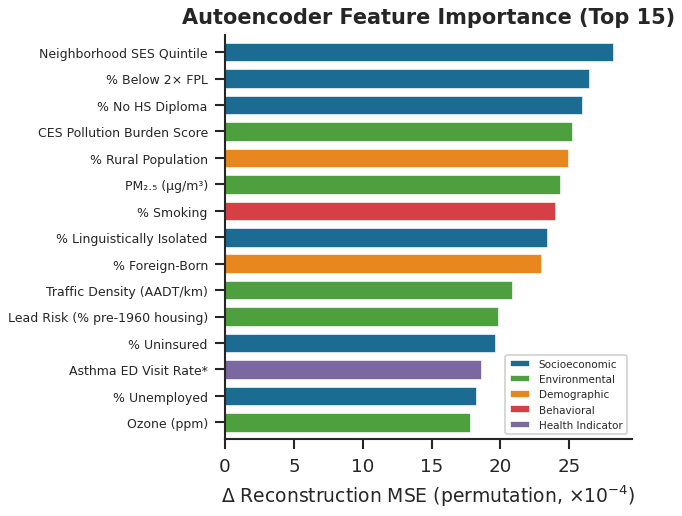

In [14]:
DOMAIN = {
    "num__QNSES":                    "Socioeconomic",
    "num__CES_Poverty":              "Socioeconomic",
    "num__CES_Education":            "Socioeconomic",
    "num__CES_Pollution_Burden":     "Environmental",
    "num__PerRural":                 "Demographic",
    "num__CES_PM2.5":                "Environmental",
    "num__PerSmoking":               "Behavioral",
    "num__CES_Linguistic_Isolation": "Socioeconomic",
    "num__PerForeignBorn":           "Demographic",
    "num__CES_Traffic":              "Environmental",
    "num__CES_Lead":                 "Environmental",
    "num__PerUninsured":             "Socioeconomic",
    "num__CES_Asthma":               "Health Indicator",
    "num__CES_Unemployment":         "Socioeconomic",
    "num__CES_Ozone":                "Environmental",
}

DOMAIN_COLORS = {
    "Socioeconomic":    "#1B6B93",
    "Environmental":    "#4E9F3D",
    "Demographic":      "#E8871E",
    "Behavioral":       "#D64045",
    "Health Indicator":  "#7B68A0",
}

fig, ax = plt.subplots(figsize=(3.5, 3.5))
y_pos = range(len(top15))

features_reversed = top15["feature"].values[::-1]
bar_colors = [DOMAIN_COLORS.get(DOMAIN.get(f, ""), OI["blue"]) for f in features_reversed]

ax.barh(y_pos, top15["delta_mse"].values[::-1],
        color=bar_colors, edgecolor="white", linewidth=0.3, height=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels([nice(clean_name_map.get(f, f)) for f in features_reversed], fontsize=6)
ax.set_xticks([0, 5e-4, 10e-4, 15e-4, 20e-4, 25e-4])
ax.set_xticklabels([0, 5, 10, 15, 20, 25])
ax.set_xlabel(r"$\Delta$ Reconstruction MSE (permutation, $\times 10^{-4}$)", fontsize=9)
ax.margins(y=0.02)
ax.set_title("Autoencoder Feature Importance (Top 15)", fontsize=10, fontweight='bold')

# Legend showing only domains present in top 15
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=d) for d, c in DOMAIN_COLORS.items()
                  if d in {DOMAIN.get(f, "") for f in features_reversed}]
ax.legend(handles=legend_handles, fontsize=5, loc="lower right", framealpha=0.9)

savefig(fig, "fig3_ae_feature_importance")
plt.show()

## 7. Binary Classification — High vs. Low AAIR

### Objective

Classify MSSAs into **High** (AAIR ≥ 60th percentile) or **Low**
(AAIR ≤ 40th percentile) groups using the autoencoder's top-15
features. MSSAs between the 40th and 60th percentiles are excluded
to create a buffer zone that reduces label noise near the decision
boundary.

### Design

| Element | Value |
|---------|-------|
| Unit | MSSA (`Sex = 'Both'`) |
| Label | High = 1 (AAIR ≥ P60), Low = 0 (AAIR ≤ P40) |
| Features | AE top-15 |
| Leakage prevention | `StandardScaler` fitted on training fold only via `Pipeline` |
| Evaluation | 5-fold stratified CV on 80% training set; held-out 20% test set with bootstrap 95% CIs |

### Classifier Hyperparameters

| Model | Key hyperparameters |
|-------|---------------------|
| Logistic Regression | C = 1.0, penalty = 'l2', solver = 'lbfgs', max_iter = 2 000 |
| Random Forest | n_estimators = 500, max_depth = None, min_samples_leaf = 1 |
| Extra Trees | n_estimators = 500, max_depth = None, min_samples_leaf = 1 |
| Gradient Boosting | n_estimators = 100, learning_rate = 0.1, max_depth = 3 |
| XGBoost | n_estimators = 100, learning_rate = 0.1, max_depth = 6 |
| KNN | k = 11, weights = 'uniform', metric = 'minkowski' |
| SVM (RBF) | C = 1.0, gamma = 'scale', probability = True |
| MLP | hidden_layers = (100,), activation = 'relu', max_iter = 500, alpha = 1 × 10⁻⁴ |

In [15]:
# -- Create binary labels --
AAIR_series = df["AAIR"].astype(float)
q40_thr, q60_thr = np.nanpercentile(AAIR_series.dropna(), [40, 60])
print(f"AAIR percentile thresholds: P40 = {q40_thr:.2f}, P60 = {q60_thr:.2f}")

labels = np.full(N_MSSA, np.nan)
labels[AAIR_series <= q40_thr] = 0
labels[AAIR_series >= q60_thr] = 1
mask_cls = ~np.isnan(labels)
y_bin = labels[mask_cls].astype(int)

# Use AE top-15 features
feat_names_15 = top15["feature"].tolist()
X_selected_all = pd.DataFrame(X_feat, columns=feature_names)[feat_names_15]
X_selected = X_selected_all.iloc[mask_cls].values.astype(np.float32)


N_cls = len(y_bin)
n_pos = y_bin.sum(); n_neg = N_cls - n_pos
print(f"MSSAs retained (below P40 + above P60): {N_cls} / {N_MSSA}")
print(f"  Class balance: {n_pos} high / {n_neg} low")

# -- Train/test split --
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_bin,
    test_size=0.2, stratify=y_bin, random_state=SEED)
print(f"  Train: {len(y_train)} MSSAs | Test: {len(y_test)} MSSAs")


AAIR percentile thresholds: P40 = 38.00, P60 = 43.00
MSSAs retained (below P40 + above P60): 420 / 542
  Class balance: 211 high / 209 low
  Train: 336 MSSAs | Test: 84 MSSAs


In [16]:
# ── Model zoo (all hyperparameters stated) ───────────────────────────────────
def make_zoo() -> Dict[str, object]:
    zoo = {
        "Logistic Regression": LogisticRegression(
            C=1.0, penalty="l2", solver="lbfgs", max_iter=2000, random_state=SEED),
        "Random Forest": RandomForestClassifier(
            n_estimators=500, max_depth=None, min_samples_leaf=1,
            random_state=SEED, n_jobs=-1),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.1, max_depth=3, random_state=SEED),
        "Extra Trees": ExtraTreesClassifier(
            n_estimators=500, max_depth=None, min_samples_leaf=1,
            random_state=SEED, n_jobs=-1),
        "KNN (k=11)": KNeighborsClassifier(n_neighbors=11, weights="uniform"),
        "SVM (RBF)": SVC(C=1.0, kernel="rbf", gamma="scale",
                         probability=True, random_state=SEED),
        "MLP": MLPClassifier(hidden_layer_sizes=(100,), activation="relu",
                             max_iter=500, alpha=1e-4, random_state=SEED),
    }
    if HAS_XGB:
        zoo["XGBoost"] = xgb.XGBClassifier(
            n_estimators=100, learning_rate=0.1, max_depth=6,
            use_label_encoder=False, eval_metric="logloss",
            random_state=SEED, n_jobs=-1)
    return zoo

# ── 5-Fold Random Stratified CV ─────────────────────────────────────────────
# Scaler is fit inside each fold to prevent leakage
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
zoo = make_zoo()

cv_rows = []
for name, base_clf in zoo.items():
    pipe = Pipeline([("scl", StandardScaler()), ("clf", clone(base_clf))])
    aucs, accs, f1s, pres, recs, mccs = [], [], [], [], [], []
    for tr_idx, va_idx in skf.split(X_train, y_train):
        Xtr, Xva = X_train[tr_idx], X_train[va_idx]
        ytr, yva = y_train[tr_idx], y_train[va_idx]
        pipe_fold = clone(pipe)
        pipe_fold.fit(Xtr, ytr)
        proba = pipe_fold.predict_proba(Xva)[:, 1]
        pred = (proba >= 0.5).astype(int)
        aucs.append(roc_auc_score(yva, proba))
        accs.append(accuracy_score(yva, pred))
        f1s.append(f1_score(yva, pred))
        pres.append(precision_score(yva, pred))
        recs.append(recall_score(yva, pred))
        mccs.append(matthews_corrcoef(yva, pred))

    cv_rows.append({
        "Model": name,
        "AUC-ROC": f"{np.mean(aucs):.3f} +/- {np.std(aucs):.3f}",
        "Accuracy": f"{np.mean(accs):.3f} +/- {np.std(accs):.3f}",
        "F1": f"{np.mean(f1s):.3f} +/- {np.std(f1s):.3f}",
        "Precision": f"{np.mean(pres):.3f} +/- {np.std(pres):.3f}",
        "Recall": f"{np.mean(recs):.3f} +/- {np.std(recs):.3f}",
        "MCC": f"{np.mean(mccs):.3f} +/- {np.std(mccs):.3f}",
        "_auc_mean": np.mean(aucs),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("_auc_mean", ascending=False)
best_name = cv_df.iloc[0]["Model"]
print(f"Table 2: 5-Fold Random CV Performance (N = {len(y_train)} training MSSAs)")
print(cv_df.drop(columns="_auc_mean").to_string(index=False))
print(f"\nBest model by AUC-ROC: {best_name}")
cv_df.drop(columns="_auc_mean").to_csv(os.path.join(OUTDIR, "table2_cv_performance.csv"), index=False)

Table 2: 5-Fold Random CV Performance (N = 336 training MSSAs)
              Model         AUC-ROC        Accuracy              F1       Precision          Recall             MCC
      Random Forest 0.895 +/- 0.035 0.833 +/- 0.040 0.834 +/- 0.040 0.835 +/- 0.038 0.834 +/- 0.051 0.667 +/- 0.079
            XGBoost 0.892 +/- 0.037 0.827 +/- 0.047 0.822 +/- 0.055 0.844 +/- 0.036 0.804 +/- 0.082 0.657 +/- 0.093
        Extra Trees 0.889 +/- 0.036 0.836 +/- 0.023 0.839 +/- 0.023 0.829 +/- 0.032 0.852 +/- 0.035 0.674 +/- 0.046
  Gradient Boosting 0.885 +/- 0.036 0.800 +/- 0.050 0.800 +/- 0.059 0.799 +/- 0.034 0.804 +/- 0.093 0.604 +/- 0.098
          SVM (RBF) 0.880 +/- 0.021 0.845 +/- 0.040 0.850 +/- 0.036 0.833 +/- 0.049 0.869 +/- 0.046 0.693 +/- 0.078
                MLP 0.874 +/- 0.037 0.827 +/- 0.046 0.827 +/- 0.052 0.825 +/- 0.036 0.834 +/- 0.079 0.657 +/- 0.090
Logistic Regression 0.870 +/- 0.014 0.813 +/- 0.020 0.810 +/- 0.028 0.823 +/- 0.032 0.804 +/- 0.069 0.628 +/- 0.041
         

### Held-Out Test-Set Evaluation with Bootstrap Confidence Intervals

The best-performing model (by cross-validated AUC-ROC) is refit on the
full training set and evaluated on the 20% held-out test set.
Non-parametric bootstrap resampling (*B* = 2 000) provides 95%
confidence intervals for all performance metrics.

In [17]:
# ── Refit best model & bootstrap CIs on test set ────────────────────────────
best_pipe = Pipeline([("scl", StandardScaler()),
                       ("clf", clone(make_zoo()[best_name]))])
best_pipe.fit(X_train, y_train)
test_proba = best_pipe.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

B = 2000
boot_metrics = {m: [] for m in ["AUC", "Accuracy", "F1", "Precision", "Recall", "MCC", "Brier"]}

for _ in range(B):
    idx = rng.choice(len(y_test), size=len(y_test), replace=True)
    yb, pb, predb = y_test[idx], test_proba[idx], test_pred[idx]
    if len(np.unique(yb)) < 2: continue
    boot_metrics["AUC"].append(roc_auc_score(yb, pb))
    boot_metrics["Accuracy"].append(accuracy_score(yb, predb))
    boot_metrics["F1"].append(f1_score(yb, predb, zero_division=0))
    boot_metrics["Precision"].append(precision_score(yb, predb, zero_division=0))
    boot_metrics["Recall"].append(recall_score(yb, predb, zero_division=0))
    boot_metrics["MCC"].append(matthews_corrcoef(yb, predb))
    boot_metrics["Brier"].append(brier_score_loss(yb, pb))

ci_rows = []
print(f"Test-Set Performance with Bootstrap 95% CIs (B={B})")
print(f"Model: {best_name}, N_test = {len(y_test)} MSSAs\n")
for m in boot_metrics:
    vals = np.array(boot_metrics[m])
    pt = {"AUC": roc_auc_score(y_test, test_proba),
          "Accuracy": accuracy_score(y_test, test_pred),
          "F1": f1_score(y_test, test_pred),
          "Precision": precision_score(y_test, test_pred),
          "Recall": recall_score(y_test, test_pred),
          "MCC": matthews_corrcoef(y_test, test_pred),
          "Brier": brier_score_loss(y_test, test_proba)}[m]
    lo, hi = np.percentile(vals, [2.5, 97.5])
    ci_rows.append({"Metric": m, "Point": round(pt, 4),
                     "CI_lower": round(lo, 4), "CI_upper": round(hi, 4)})
    print(f"  {m:12s}: {pt:.3f}  [{lo:.3f} – {hi:.3f}]")

pd.DataFrame(ci_rows).to_csv(os.path.join(OUTDIR, "test_bootstrap_CIs.csv"), index=False)

Test-Set Performance with Bootstrap 95% CIs (B=2000)
Model: Random Forest, N_test = 84 MSSAs

  AUC         : 0.931  [0.868 – 0.979]
  Accuracy    : 0.845  [0.762 – 0.917]
  F1          : 0.835  [0.737 – 0.915]
  Precision   : 0.892  [0.778 – 0.974]
  Recall      : 0.786  [0.657 – 0.902]
  MCC         : 0.695  [0.531 – 0.836]
  Brier       : 0.111  [0.079 – 0.148]


## Figure 4 — ROC, Precision–Recall, and Calibration Curves

Three complementary views of the best model's test-set performance:

- **Panel A (ROC):** Sensitivity vs. 1 − specificity; the diagonal
  represents chance-level discrimination.
- **Panel B (Precision–Recall):** Particularly informative when class
  prevalence is moderate; average precision (AP) summarises the curve.
- **Panel C (Calibration):** Observed event frequency vs. predicted
  probability; the diagonal represents perfect calibration.

  Saved → ./publication_outputs/fig4_ROC_PR_calibration.png


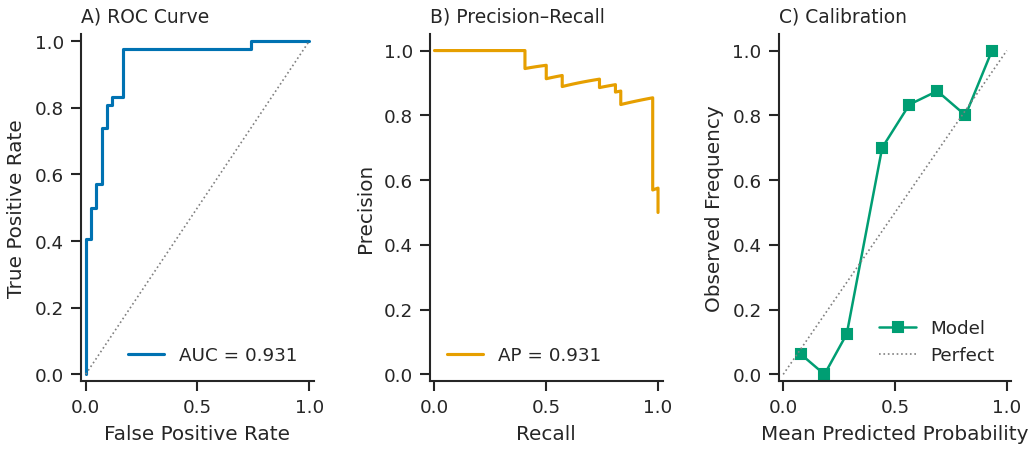

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(8.0, 3.0), gridspec_kw={"wspace": 0.50})

ax = axes[0]
fpr, tpr, _ = roc_curve(y_test, test_proba)
auc_val = roc_auc_score(y_test, test_proba)
ax.plot(fpr, tpr, color=OI["blue"], linewidth=1.5, label=f"AUC = {auc_val:.3f}")
ax.plot([0, 1], [0, 1], color="grey", linestyle=":", linewidth=0.8)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(frameon=False, loc="lower right")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_title("A) ROC Curve", fontsize=9, loc="left")

ax = axes[1]
prec_arr, rec_arr, _ = precision_recall_curve(y_test, test_proba)
ap = average_precision_score(y_test, test_proba)
ax.plot(rec_arr, prec_arr, color=OI["orange"], linewidth=1.5, label=f"AP = {ap:.3f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(frameon=False, loc="lower left")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
ax.set_title("B) Precision–Recall", fontsize=9, loc="left")

ax = axes[2]
prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=8, strategy="uniform")
ax.plot(prob_pred, prob_true, "s-", color=OI["green"], markersize=5, linewidth=1.2, label="Model")
ax.plot([0, 1], [0, 1], color="grey", linestyle=":", linewidth=0.8, label="Perfect")
ax.set_xlabel("Mean Predicted Probability"); ax.set_ylabel("Observed Frequency")
ax.legend(frameon=False, loc="lower right")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
ax.set_title("C) Calibration", fontsize=9, loc="left")

fig.tight_layout()
savefig(fig, "fig4_ROC_PR_calibration")
plt.show()

## Figure 5 — Confusion Matrix

The confusion matrix shows the percentage (and raw count) of correct and
incorrect classifications on the held-out test set. Rows represent the
true labels; columns represent the predicted labels.

  Saved → ./publication_outputs/fig5_confusion_matrix.png


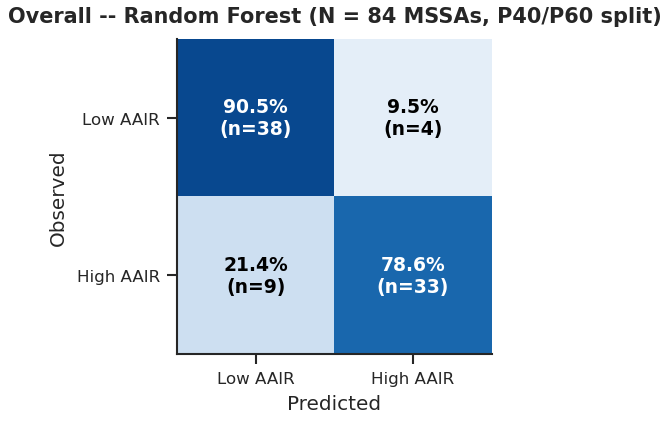

In [19]:
cm_raw, cm_pct = plot_confusion_pct(
    y_test, test_pred,
    labels=["Low AAIR", "High AAIR"],
    title=f"Overall -- {best_name} (N = {len(y_test)} MSSAs, P40/P60 split)",
    save_name="fig5_confusion_matrix")
pd.DataFrame(cm_pct.round(1),
             columns=["Pred Low %", "Pred High %"],
             index=["True Low", "True High"]).to_csv(
    os.path.join(OUTDIR, "confusion_matrix_overall.csv"))


## 8. SHAP Interpretability

**SHapley Additive exPlanations (SHAP)** decompose each prediction into
per-feature contributions, providing both *local* (per-MSSA) and *global*
(population-level) interpretability. We use a model-agnostic
`shap.Explainer` with an independent masker fitted on a random background
subset of 256 training MSSAs, applied to up to 512 test MSSAs.

- **Beeswarm plot (Figure 6a):** Each dot is one MSSA; the x-position
  shows the SHAP value (impact on model output), and colour encodes the
  feature value (red = high, blue = low).
- **Bar plot (Figure 6b):** Mean absolute SHAP value per feature — a
  global importance ranking that accounts for non-linearities and
  interactions captured by the model.

PermutationExplainer explainer: 85it [01:36,  1.20s/it]                        


  Saved → ./publication_outputs/fig6a_shap_beeswarm.png


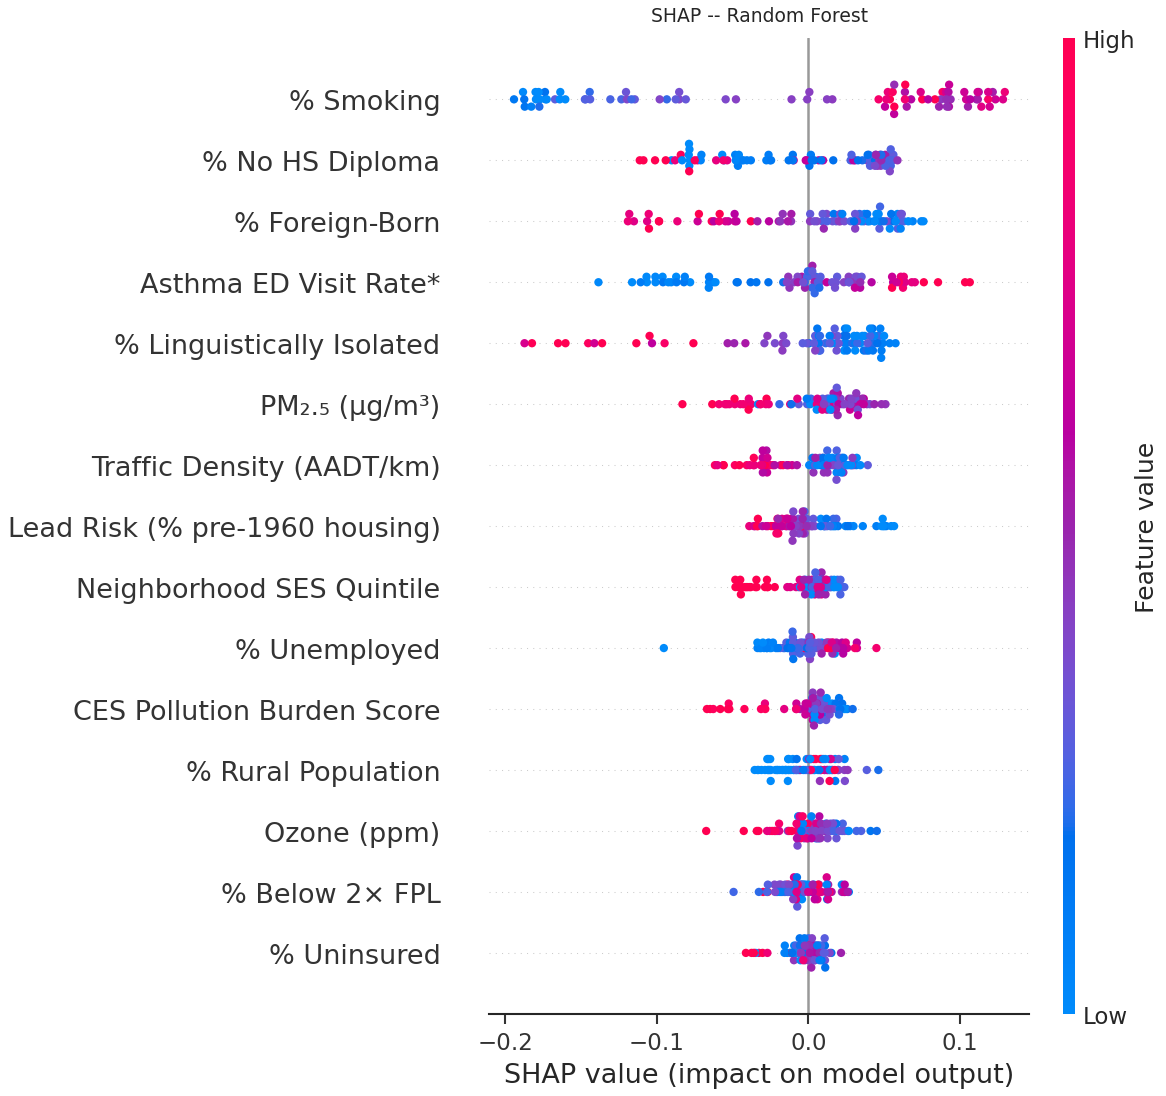

  Saved → ./publication_outputs/fig6b_shap_bar.png


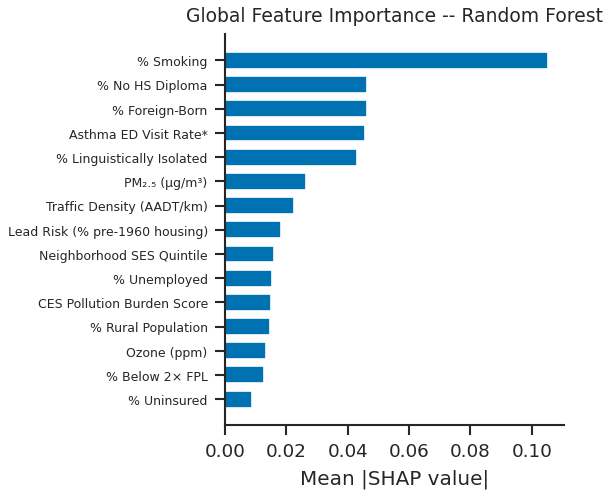

SHAP analysis complete.


In [20]:
if HAS_SHAP:
    bg_n = min(256, len(X_train))
    bg = X_train[rng.choice(len(X_train), size=bg_n, replace=False)]
    te_n = min(512, len(X_test))
    idx_s = rng.choice(len(X_test), size=te_n, replace=False)
    Xte_shap = X_test[idx_s]

    predict_fn = lambda x: best_pipe.predict_proba(x)[:, 1]
    explainer = shap.Explainer(predict_fn, shap.maskers.Independent(bg))
    sv = explainer(Xte_shap)
    shap_vals = np.asarray(sv.values)

    nice_feat15 = [nice(clean_name_map.get(f, f)) for f in feat_names_15]

    def shap_beeswarm(vals, data, names, save_name, title=None, figsize=(5.0, 4.5)):
        fig, ax = plt.subplots(figsize=figsize)
        shap.plots.beeswarm(
            shap.Explanation(values=vals, data=data, feature_names=names),
            max_display=15, show=False)
        if title: plt.title(title, fontsize=9, pad=8)
        fig.tight_layout()
        savefig(fig, save_name)
        plt.show()

    shap_beeswarm(shap_vals, Xte_shap, nice_feat15,
                  "fig6a_shap_beeswarm", title=f"SHAP -- {best_name}")

    fig, ax = plt.subplots(figsize=(4.0, 3.5))
    mean_abs = np.abs(shap_vals).mean(axis=0)
    order = np.argsort(mean_abs)
    ax.barh(range(len(order)), mean_abs[order], color=OI["blue"], height=0.7)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([nice_feat15[i] for i in order], fontsize=6)
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(f"Global Feature Importance -- {best_name}", fontsize=9)
    fig.tight_layout()
    savefig(fig, "fig6b_shap_bar")
    plt.show()

    pd.DataFrame(shap_vals, columns=feat_names_15).to_csv(
        os.path.join(OUTDIR, "shap_values_overall.csv"), index=False)
    pd.DataFrame(Xte_shap, columns=feat_names_15).to_csv(
        os.path.join(OUTDIR, "shap_X_overall.csv"), index=False)
    print("SHAP analysis complete.")


## 9. Race/Ethnicity-Stratified Sub-Cohort Evaluation

**Unit:** MSSA. For each racial/ethnic group, only MSSAs with
non-suppressed race-specific AAIR are included. Binary labels use the
40th/60th percentile cutoffs *within each racial/ethnic group*, yielding
group-specific definitions of "High" and "Low."

Two models are compared for each group:
1. **Race-specific model** — trained and tested exclusively on MSSAs
   with non-suppressed rates for that group.
2. **Pooled baseline** — the model trained on overall AAIR (Section 7),
   applied to the same race-specific test MSSAs without retraining.

This comparison reveals whether race-specific patterns are captured by the
overall model or require dedicated training. SHAP beeswarm plots and
confusion matrices are generated per group.

Pooled baseline trained on n = 420 MSSAs (40th/60th pctl of overall AAIR)


PermutationExplainer explainer: 82it [01:27,  1.22s/it]                        


  Saved → ./publication_outputs/shap_White_AAIR.png


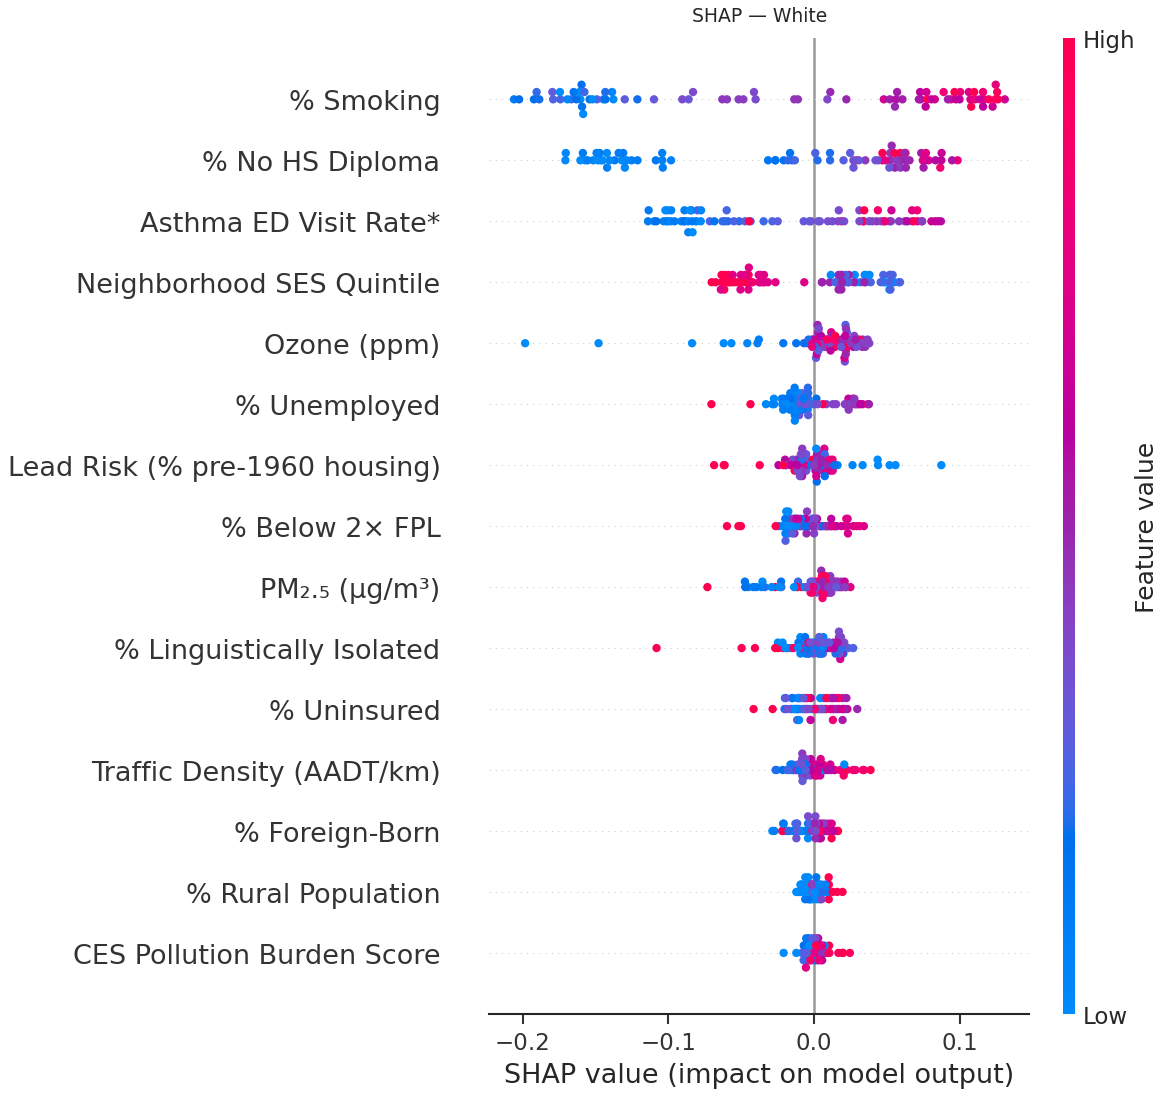

  Saved → ./publication_outputs/cm_White_AAIR.png


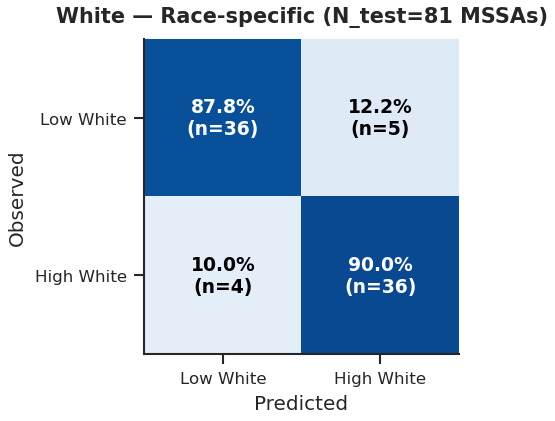

PermutationExplainer explainer: 33it [00:34,  1.52s/it]                        


  Saved → ./publication_outputs/shap_Black_AAIR.png


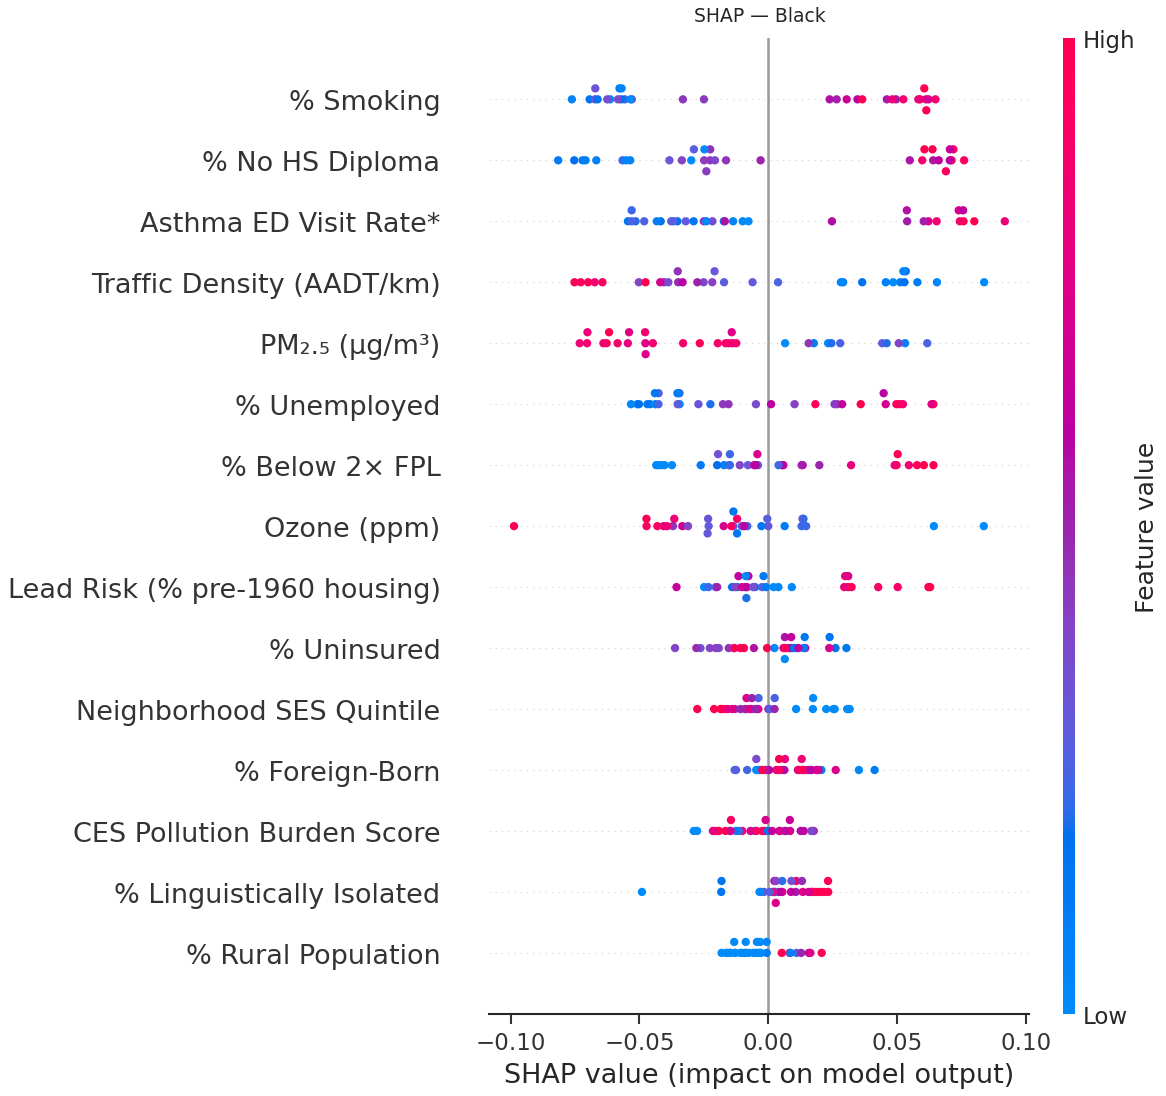

  Saved → ./publication_outputs/cm_Black_AAIR.png


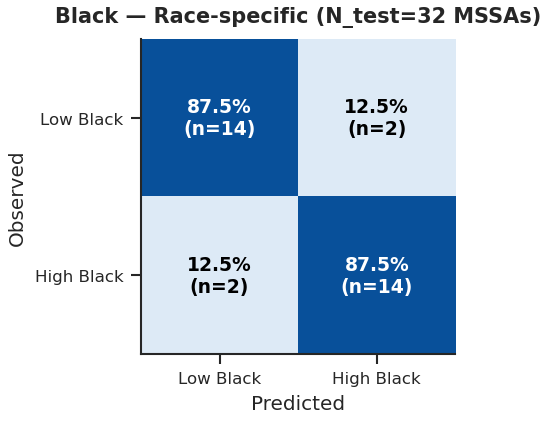

PermutationExplainer explainer: 60it [01:04,  1.28s/it]                        


  Saved → ./publication_outputs/shap_Hispanic_AAIR.png


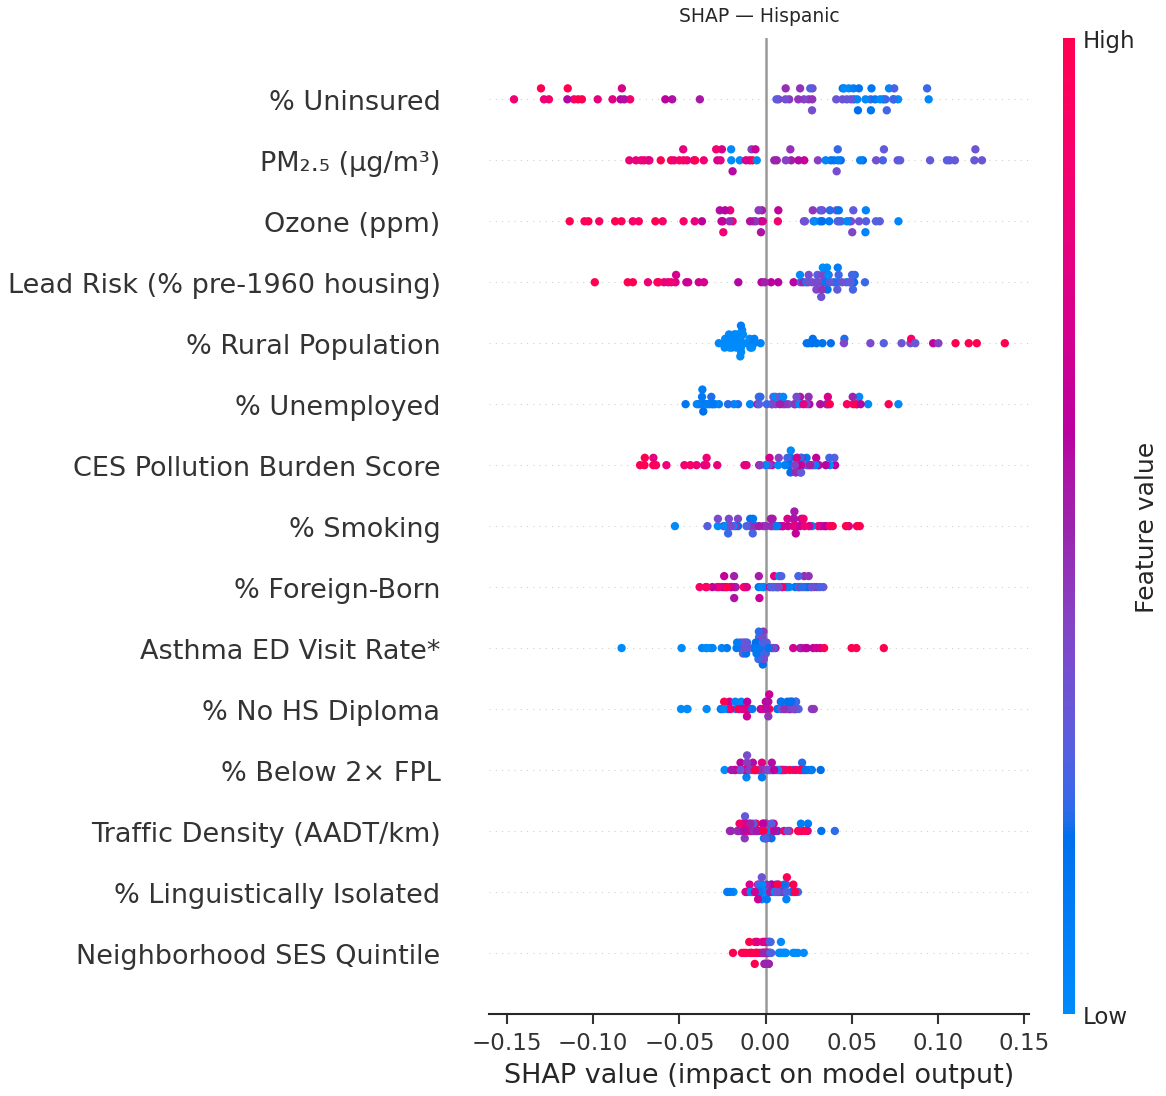

  Saved → ./publication_outputs/cm_Hispanic_AAIR.png


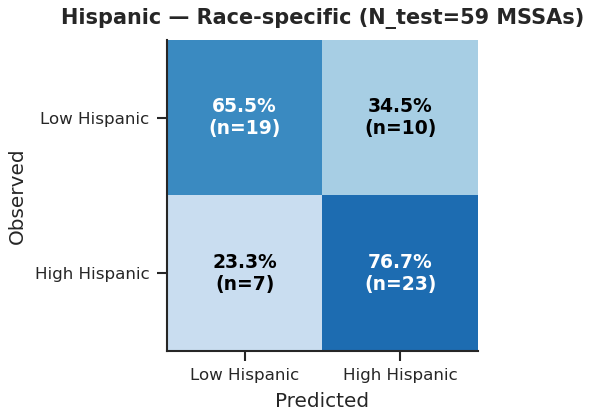

PermutationExplainer explainer: 47it [00:50,  1.36s/it]                        


  Saved → ./publication_outputs/shap_Asian_AAIR.png


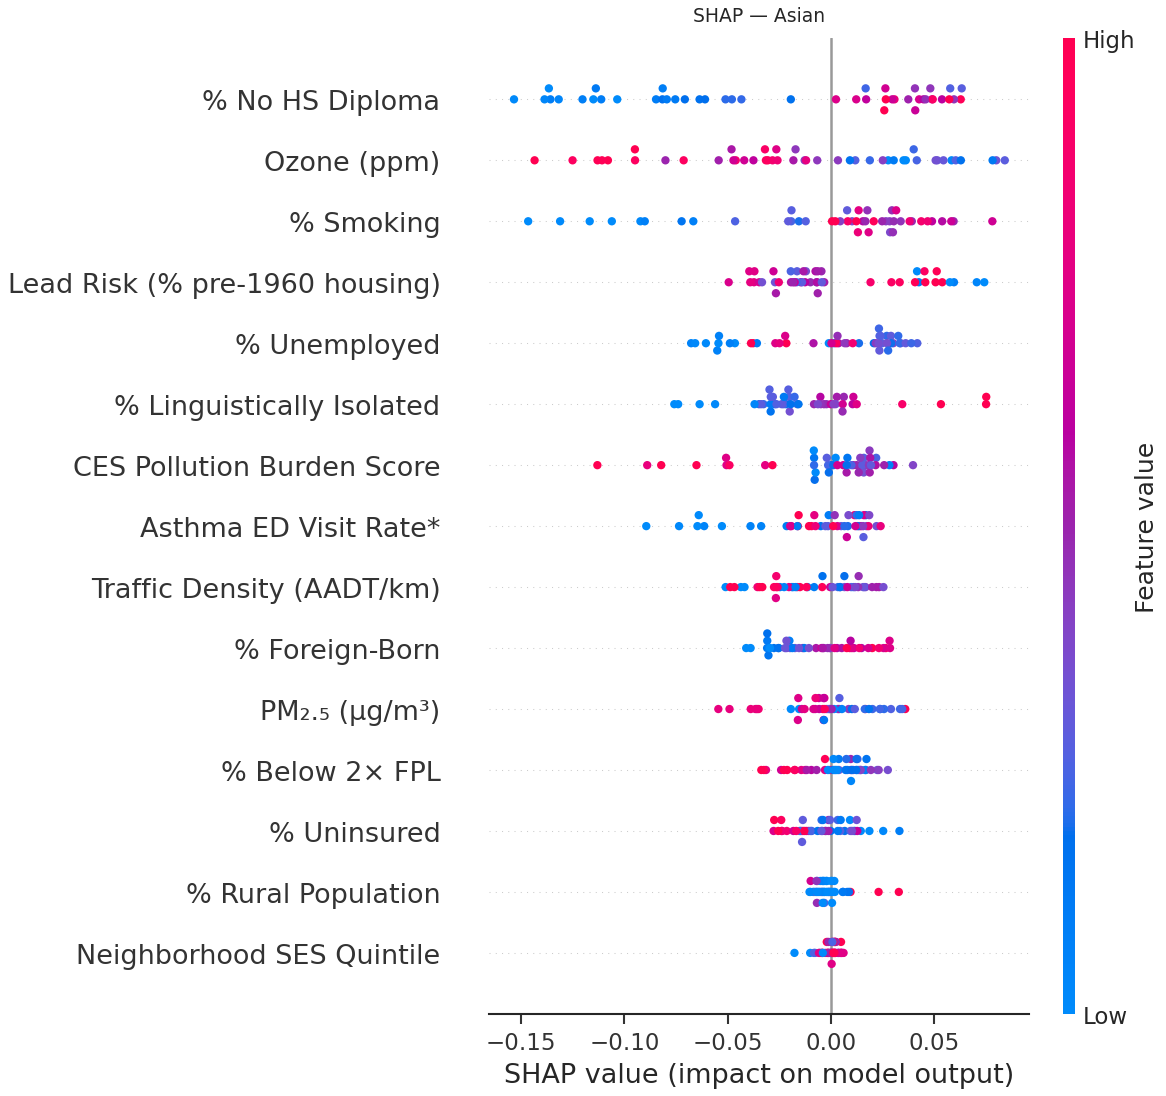

  Saved → ./publication_outputs/cm_Asian_AAIR.png


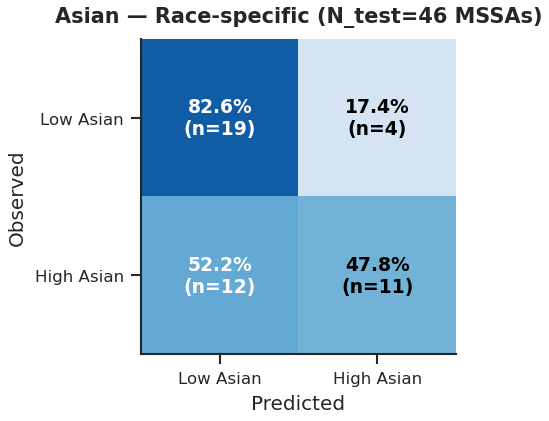


Table 3: Race-Stratified Performance
    Race           Model  N_MSSA_available  N_classification  N_test   AUC  Accuracy    F1  Precision  Recall   MCC  Brier
   White   Race-specific               504               404      81 0.947     0.889 0.889      0.878   0.900 0.778  0.097
   White Pooled baseline               504               404      81 0.805     0.753 0.730      0.794   0.675 0.511  0.199
   Black   Race-specific               196               159      32 0.914     0.875 0.875      0.875   0.875 0.750  0.119
   Black Pooled baseline               196               159      32 0.824     0.719 0.667      0.818   0.562 0.461  0.207
Hispanic   Race-specific               362               292      59 0.713     0.712 0.730      0.697   0.767 0.425  0.214
Hispanic Pooled baseline               362               292      59 0.724     0.644 0.588      0.714   0.500 0.306  0.266
   Asian   Race-specific               281               227      46 0.736     0.652 0.579      0.733

In [21]:
def make_quartile_labels(series, lo_pct=40, hi_pct=60, min_n=40):
    s = pd.to_numeric(series, errors="coerce").astype(float)
    s_valid = s.dropna()
    if s_valid.empty:
        return np.zeros(len(s), dtype=bool), np.array([], dtype=int)
    q_lo, q_hi = np.nanpercentile(s_valid.values, [lo_pct, hi_pct])
    y = np.full(len(s), np.nan)
    y[s <= q_lo] = 0; y[s >= q_hi] = 1
    m = ~np.isnan(y)
    y_kept = y[m].astype(int)
    if len(np.unique(y_kept)) < 2 or len(y_kept) < min_n:
        return np.zeros(len(s), dtype=bool), np.array([], dtype=int)
    return m, y_kept

# ── Build pooled baseline on overall AAIR top/bottom 20th pctl ──────────────
m_pooled, y_pooled = make_quartile_labels(df["AAIR"])
X_pooled = X_selected_all.iloc[m_pooled].values.astype(np.float32)
pooled_pipe = Pipeline([("scl", StandardScaler()),
                         ("clf", RandomForestClassifier(
                            n_estimators=500, max_depth=None, min_samples_leaf=1,
                            random_state=SEED, n_jobs=-1))])
pooled_pipe.fit(X_pooled, y_pooled)
print(f"Pooled baseline trained on n = {len(y_pooled)} MSSAs (40th/60th pctl of overall AAIR)")

strat_rows = []
for rc in race_cols:
    if rc not in race_df.columns: continue
    m_r, y_r = make_quartile_labels(race_df[rc])
    if y_r.size == 0:
        print(f"  {rc}: skipped (too few MSSAs)")
        continue

    X_r = X_selected_all.iloc[m_r].values.astype(np.float32)
    n_avail = race_df[rc].notna().sum()
    Xtr, Xte, ytr, yte = train_test_split(
        X_r, y_r, test_size=0.2, stratify=y_r, random_state=SEED)

    # Race-specific model
    spec_pipe = Pipeline([("scl", StandardScaler()),
                           ("clf", RandomForestClassifier(
                            n_estimators=500, max_depth=None, min_samples_leaf=1,
                            random_state=SEED, n_jobs=-1))])
    spec_pipe.fit(Xtr, ytr)
    spec_proba = spec_pipe.predict_proba(Xte)[:, 1]
    spec_pred = (spec_proba >= 0.5).astype(int)

    # Pooled baseline
    pool_proba = pooled_pipe.predict_proba(Xte)[:, 1]
    pool_pred = (pool_proba >= 0.5).astype(int)

    race_label = rc.replace("_AAIR", "")
    for model_name, proba, pred in [("Race-specific", spec_proba, spec_pred),
                                      ("Pooled baseline", pool_proba, pool_pred)]:
        auc = roc_auc_score(yte, proba) if len(np.unique(yte)) == 2 else np.nan
        strat_rows.append({
            "Race": race_label, "Model": model_name,
            "N_MSSA_available": n_avail,
            "N_classification": len(y_r),
            "N_test": len(yte),
            "AUC": round(auc, 3) if not np.isnan(auc) else "N/A",
            "Accuracy": round(accuracy_score(yte, pred), 3),
            "F1": round(f1_score(yte, pred, zero_division=0), 3),
            "Precision": round(precision_score(yte, pred, zero_division=0), 3),
            "Recall": round(recall_score(yte, pred, zero_division=0), 3),
            "MCC": round(matthews_corrcoef(yte, pred), 3),
            "Brier": round(brier_score_loss(yte, proba), 3),
        })

    # SHAP for race-specific model
    if HAS_SHAP:
        bg_r = Xtr[rng.choice(len(Xtr), min(100, len(Xtr)), replace=False)]
        exp_r = shap.Explainer(lambda x: spec_pipe.predict_proba(x)[:, 1],
                                shap.maskers.Independent(bg_r))
        sv_r = exp_r(Xte)
        shap_beeswarm(np.asarray(sv_r.values), Xte, nice_feat15,
                      f"shap_{rc}", title=f"SHAP — {race_label}")

    # Confusion matrix
    plot_confusion_pct(yte, spec_pred,
                       labels=[f"Low {race_label}", f"High {race_label}"],
                       title=f"{race_label} — Race-specific (N_test={len(yte)} MSSAs)",
                       save_name=f"cm_{rc}")

strat_df = pd.DataFrame(strat_rows)
print("\nTable 3: Race-Stratified Performance")
print(strat_df.to_string(index=False))
strat_df.to_csv(os.path.join(OUTDIR, "table3_race_stratified.csv"), index=False)

## 10. Algorithmic Fairness Audit

### Motivation

Predictive models applied to health data risk perpetuating or amplifying
existing disparities if their error rates differ systematically across
population subgroups. We audit the overall classifier for fairness using
the **majority race/ethnicity** of each MSSA (defined as the racial/ethnic
group comprising the plurality of the population) as the protected
attribute.

### Metrics

- **True Positive Rate (TPR)** and **False Positive Rate (FPR)** per
  majority-race group — equalized odds.
- **Positive prediction rate** per group — demographic parity.
- **Disparate Impact Ratio** = min(positive rate) / max(positive rate);
  a threshold of 0.80 is reported for context, interpreted cautiously
  given the ecological unit of analysis.
- **Bootstrap 95% CIs** for the disparate impact ratio (*B* = 2 000).

In [22]:
# ── Define majority race per MSSA ────────────────────────────────────────────
race_pct_cols = {
    "PerWhite": "White", "PerBlack": "Black",
    "PerHispanic": "Hispanic", "PerAsian": "Asian"
}
available_pct = {k: v for k, v in race_pct_cols.items() if k in df_mssa.columns}

if available_pct:
    pct_df = df_mssa[list(available_pct.keys())].copy()
    pct_df.columns = [available_pct[c] for c in pct_df.columns]
    df["majority_race"] = pct_df.idxmax(axis=1)
    print("Majority race distribution across all MSSAs:")
    print(df["majority_race"].value_counts().to_string())

# ── Fairness on test set of overall classifier ───────────────────────────────
test_indices = np.where(mask_cls)[0]  # indices into df of MSSAs in classification
# Map test set back to df indices
# We need the original indices before train_test_split
# Rebuild the index mapping
all_cls_indices = np.arange(N_cls)  # indices into X_selected
_, test_local_idx = train_test_split(
    all_cls_indices, test_size=0.2, stratify=y_bin, random_state=SEED)

mssa_indices_cls = np.where(mask_cls)[0]  # indices into df
test_mssa_idx = mssa_indices_cls[test_local_idx]

test_majority = df["majority_race"].iloc[test_mssa_idx].values

fairness_rows = []
unique_races = [r for r in ["White", "Hispanic", "Black", "Asian"] if r in test_majority]

for race in unique_races:
    race_mask = test_majority == race
    if race_mask.sum() < 5: continue
    yt_r = y_test[race_mask]
    pp_r = test_pred[race_mask]
    pr_r = test_proba[race_mask]
    tp = ((pp_r == 1) & (yt_r == 1)).sum()
    fn = ((pp_r == 0) & (yt_r == 1)).sum()
    fp = ((pp_r == 1) & (yt_r == 0)).sum()
    tn = ((pp_r == 0) & (yt_r == 0)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    pos_rate = pp_r.mean()
    fairness_rows.append({
        "Majority_Race": race, "N_test": int(race_mask.sum()),
        "TPR": round(tpr, 3) if not np.isnan(tpr) else "N/A",
        "FPR": round(fpr_val, 3) if not np.isnan(fpr_val) else "N/A",
        "Positive_Rate": round(pos_rate, 3),
    })

fair_df = pd.DataFrame(fairness_rows)

# Disparate impact ratio (min positive rate / max positive rate)
pos_rates = [r["Positive_Rate"] for r in fairness_rows if isinstance(r["Positive_Rate"], float)]
if len(pos_rates) >= 2:
    di_ratio = min(pos_rates) / max(pos_rates)
    tpr_vals = [r["TPR"] for r in fairness_rows if isinstance(r["TPR"], float)]
    fpr_vals = [r["FPR"] for r in fairness_rows if isinstance(r["FPR"], float)]
    print(f"Disparate impact ratio: {di_ratio:.3f} (threshold context: ≥ 0.80)")
    if tpr_vals:
        print(f"Equalized-odds gap (TPR): {max(tpr_vals) - min(tpr_vals):.3f}")
    if fpr_vals:
        print(f"Equalized-odds gap (FPR): {max(fpr_vals) - min(fpr_vals):.3f}")

print("\nFairness Metrics by Majority Race of MSSA")
print(fair_df.to_string(index=False))

# ── Bootstrap CIs for disparate impact ───────────────────────────────────────
di_boots = []
for _ in range(2000):
    idx_b = rng.choice(len(y_test), len(y_test), replace=True)
    pred_b = test_pred[idx_b]
    maj_b = test_majority[idx_b]
    rates_b = []
    for r in unique_races:
        rm = maj_b == r
        if rm.sum() >= 3:
            rates_b.append(pred_b[rm].mean())
    if len(rates_b) >= 2 and max(rates_b) > 0:
        di_boots.append(min(rates_b) / max(rates_b))

if di_boots:
    lo_di, hi_di = np.percentile(di_boots, [2.5, 97.5])
    print(f"\nDisparate Impact 95% CI: [{lo_di:.3f} – {hi_di:.3f}]")

fair_df.to_csv(os.path.join(OUTDIR, "fairness_metrics.csv"), index=False)

Majority race distribution across all MSSAs:
majority_race
White       315
Hispanic    191
Asian        35
Black         1
Disparate impact ratio: 0.000 (threshold context: ≥ 0.80)
Equalized-odds gap (TPR): 0.806
Equalized-odds gap (FPR): 0.143

Fairness Metrics by Majority Race of MSSA
Majority_Race  N_test   TPR   FPR  Positive_Rate
        White      52 0.806 0.143          0.538
     Hispanic      27 0.800 0.059          0.333
        Asian       5 0.000 0.000          0.000

Disparate Impact 95% CI: [0.000 – 0.772]


## 11. Sensitivity Analyses

Three sensitivity analyses probe the robustness of the classification
results:

### 11a. Percentile-Cutoff Sweep

The choice of P40/P60 thresholds is inherently arbitrary. To assess how
sensitive model performance is to this choice, we sweep the cutoff from
5% to 50% per tail (i.e., the most extreme 5%–50% of MSSAs in each
direction) and report 10-fold CV AUC-ROC for all eight classifiers at
each cutoff.

### 11b. Excluding Health-Outcome Predictors

Asthma ED visit rate, CVD mortality rate, and low birth weight are
downstream health outcomes that could act as proxies for the outcome
(lung cancer incidence). Removing them tests whether classification
performance is driven by genuine environmental/socioeconomic signal
rather than outcome–predictor conflation.

### 11c. Population-Weighted Classification

If MSSA total population is available, a population-weighted
classification can down-weight rate estimates from small-population
MSSAs, addressing rate instability.

In [23]:
# ── 12a. Quartile-cutoff sweep ───────────────────────────────────────────────
TARGET_COL = "AAIR"
PERCENTS = np.linspace(5, 50, 46)
N_SPLITS = 10

FORCE_EXCLUDE = {TARGET_COL, "AreaID", "URL", "Sex", "Cancer", "Cancer Years",
                 "PopTot", "PopDensity_sqmi_calc"}
num_feat_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feat_cols_sweep = [c for c in num_feat_cols if c not in FORCE_EXCLUDE]
y_all_sweep = df[TARGET_COL].astype(float)

def top_bottom_mask(series, pct):
    lo_q = series.quantile(pct / 100)
    hi_q = series.quantile(1.0 - pct / 100)
    return (series <= lo_q) | (series >= hi_q)

cv_sweep = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
sweep_rows = []

for p in tqdm(PERCENTS, desc="Cutoff sweep"):
    mask_s = top_bottom_mask(y_all_sweep.dropna(), p)
    idx_s = y_all_sweep.dropna().index[mask_s]
    ys = (y_all_sweep.loc[idx_s] >= y_all_sweep.quantile(1 - p/100)).astype(int).values
    Xs = df.loc[idx_s, feat_cols_sweep].values.astype(np.float32)
    Xs = np.nan_to_num(Xs, nan=np.nanmedian(Xs, axis=0))

    if len(np.unique(ys)) < 2 or len(ys) < 40:
        continue

    for name, base_clf in make_zoo().items():
        pipe = Pipeline([("scl", StandardScaler()), ("clf", clone(base_clf))])
        try:
            scores = cross_val_score(pipe, Xs, ys, cv=cv_sweep, scoring="roc_auc",
                                      error_score=np.nan)
            sweep_rows.append({
                "fraction_per_tail": round(p, 1), "model": name,
                "score_mean": round(np.nanmean(scores), 4),
                "score_std": round(np.nanstd(scores), 4),
                "n_samples": len(ys)})
        except Exception:
            pass

df_sweep = pd.DataFrame(sweep_rows)
df_sweep.to_csv(os.path.join(OUTDIR, "cutoff_sweep_results.csv"), index=False)
print(f"Sweep complete: {len(sweep_rows)} evaluations")

Cutoff sweep: 100%|██████████| 46/46 [14:12<00:00, 18.53s/it]

Sweep complete: 368 evaluations


## Figure 7 — Classifier Performance vs. Percentile Cutoff

Each line traces one classifier's AUC-ROC (10-fold CV) as a function of
the percentile cutoff stringency. Shaded regions show ± 1 SD across
folds. More extreme cutoffs (lower values on the x-axis) yield
easier discrimination tasks with higher AUC but fewer MSSAs.

  Saved → ./publication_outputs/fig7_cutoff_sensitivity.png


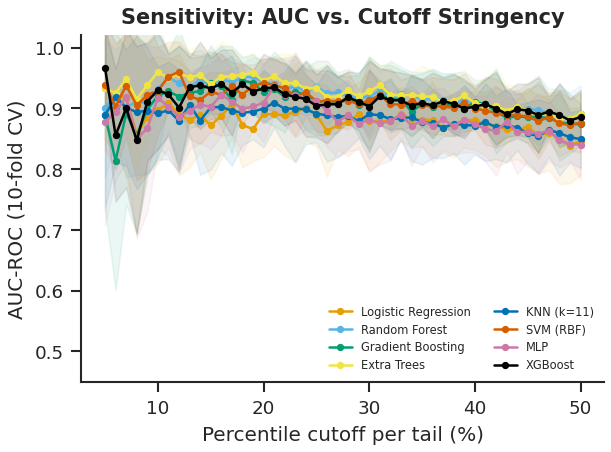

In [24]:
fig, ax = plt.subplots(figsize=(4.5, 3.0))
for i, (name, grp) in enumerate(df_sweep.groupby("model", sort=False)):
    ok = grp["score_mean"].notna()
    if not ok.any(): continue
    ax.plot(grp.loc[ok, "fraction_per_tail"], grp.loc[ok, "score_mean"],
            marker="o", markersize=2.5, linewidth=1.2, color=OI_LIST[i % len(OI_LIST)],
            label=name)
    ax.fill_between(grp.loc[ok, "fraction_per_tail"],
                    grp.loc[ok, "score_mean"] - grp.loc[ok, "score_std"],
                    grp.loc[ok, "score_mean"] + grp.loc[ok, "score_std"],
                    alpha=0.08, color=OI_LIST[i % len(OI_LIST)])
ax.set_xlabel("Percentile cutoff per tail (%)"); ax.set_ylabel("AUC-ROC (10-fold CV)")
ax.legend(frameon=False, fontsize=5.5, ncol=2, loc="lower right")
ax.set_ylim(0.45, 1.02)
ax.set_title("Sensitivity: AUC vs. Cutoff Stringency", fontsize=10, fontweight='bold')
savefig(fig, "fig7_cutoff_sensitivity")
plt.show()

### 11b. Sensitivity: Excluding Health-Outcome Predictors

The table below compares each classifier's 5-fold CV AUC-ROC with and
without the three health-outcome proxy variables (asthma, CVD mortality,
low birth weight). A negligible change in AUC suggests that
classification performance is not driven by outcome–predictor conflation.

In [25]:
# -- 12b. Sensitivity: exclude health-outcome predictors --
health_prefixed = {f"num__{v}" for v in HEALTH_OUTCOME_VARS} | HEALTH_OUTCOME_VARS
feat_no_health = [f for f in feat_names_15 if f not in health_prefixed]
removed = [f for f in feat_names_15 if f in health_prefixed]
print(f"Sensitivity analysis: excluding health-outcome indicators")
print(f"  Removed: {[nice(clean_name_map.get(f, f)) for f in removed]}")
print(f"  Remaining features: {len(feat_no_health)}")

X_nohealth = pd.DataFrame(X_feat, columns=feature_names)[feat_no_health].iloc[mask_cls].values.astype(np.float32)
Xtr_nh, Xte_nh, ytr_nh, yte_nh = train_test_split(
    X_nohealth, y_bin, test_size=0.2, stratify=y_bin, random_state=SEED)

sens_rows = []
for name, base_clf in make_zoo().items():
    pipe_nh = Pipeline([("scl", StandardScaler()), ("clf", clone(base_clf))])
    scores_nh = cross_val_score(pipe_nh, Xtr_nh, ytr_nh,
                                 cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                                 scoring="roc_auc")
    sens_rows.append({"Model": name,
                       "AUC_with_health": cv_df.set_index("Model").loc[name, "AUC-ROC"] if name in cv_df["Model"].values else "N/A",
                       "AUC_without_health": f"{np.mean(scores_nh):.3f} +/- {np.std(scores_nh):.3f}"})

sens_df = pd.DataFrame(sens_rows)
print("\nComparison: with vs without health-outcome predictors")
print(sens_df.to_string(index=False))
sens_df.to_csv(os.path.join(OUTDIR, "sensitivity_health_outcomes.csv"), index=False)


Sensitivity analysis: excluding health-outcome indicators
  Removed: ['Asthma ED Visit Rate*']
  Remaining features: 14

Comparison: with vs without health-outcome predictors
              Model AUC_with_health AUC_without_health
Logistic Regression 0.870 +/- 0.014    0.865 +/- 0.032
      Random Forest 0.895 +/- 0.035    0.881 +/- 0.036
  Gradient Boosting 0.885 +/- 0.036    0.868 +/- 0.026
        Extra Trees 0.889 +/- 0.036    0.885 +/- 0.040
         KNN (k=11) 0.858 +/- 0.030    0.848 +/- 0.034
          SVM (RBF) 0.880 +/- 0.021    0.878 +/- 0.031
                MLP 0.874 +/- 0.037    0.881 +/- 0.043
            XGBoost 0.892 +/- 0.037    0.892 +/- 0.035


## 12. Multivariable OLS Regression

### Design

A multivariable ordinary least squares (OLS) model regresses AAIR on a
parsimonious set of demographic, socioeconomic, and environmental
predictors. Key design decisions:

- **Restricted to MSSA-level data** (`Sex = 'Both'` only, *N* ≤ 542) to
  respect the ecological unit of analysis. Earlier drafts erroneously
  included all sex/race strata (*n* ≈ 1 497), inflating *N* and violating
  independence.
- **PM₂.₅ included alongside CES Pollution Burden** to distinguish the
  specific pollutant from the composite score.
- **HC3 heteroscedasticity-robust standard errors** are used throughout.
- All coefficients are interpreted as *associations* — no causal claims
  are made from ecological data.

In [26]:
# ── OLS on MSSA-level data only (Sex = 'Both', N = up to 542) ───────────────
reg_cols = ["AAIR", "PerAsian", "PerBlack", "PerHispanic",
            "QNSES", "CES_Pollution_Burden", "CES_PM2.5", "PerRural", "PerUninsured"]

# Use df_mssa (already filtered to Sex='Both')
reg_available = [c for c in reg_cols if c in df_mssa.columns]
reg = df_mssa[reg_available].dropna().copy()
N_OLS = len(reg)

y_ols = reg["AAIR"].astype(float)
X_ols = sm.add_constant(reg.drop(columns=["AAIR"]).astype(float))
ols_model = sm.OLS(y_ols, X_ols).fit(cov_type="HC3")

print(f"OLS Regression: AAIR ~ demographics + SES + pollution (HC3 SEs)")
print(f"Unit of analysis: MSSA (Sex = 'Both'), N = {N_OLS} MSSAs\n")
print(ols_model.summary())
print(f"\nR² = {ols_model.rsquared:.4f}, Adj R² = {ols_model.rsquared_adj:.4f}")

# ── VIF for OLS predictors ──────────────────────────────────────────────────
X_ols_novif = X_ols.drop(columns=["const"])
ols_vif = pd.DataFrame({
    "Variable": X_ols_novif.columns,
    "VIF": [variance_inflation_factor(X_ols_novif.values, i) for i in range(X_ols_novif.shape[1])]
})
print("\nVIF for OLS predictors:")
print(ols_vif.to_string(index=False))

# Save
ols_coef = pd.DataFrame({
    "Variable": ols_model.params.index,
    "Coef": ols_model.params.round(4).values,
    "SE_HC3": ols_model.bse.round(4).values,
    "t": ols_model.tvalues.round(3).values,
    "p": ols_model.pvalues.round(6).values,
    "CI_lower": ols_model.conf_int()[0].round(4).values,
    "CI_upper": ols_model.conf_int()[1].round(4).values,
})
ols_coef.to_csv(os.path.join(OUTDIR, "ols_coefficients.csv"), index=False)


OLS Regression: AAIR ~ demographics + SES + pollution (HC3 SEs)
Unit of analysis: MSSA (Sex = 'Both'), N = 521 MSSAs

                            OLS Regression Results                            
Dep. Variable:                   AAIR   R-squared:                       0.325
Model:                            OLS   Adj. R-squared:                  0.314
Method:                 Least Squares   F-statistic:                     20.57
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           4.42e-27
Time:                        22:12:20   Log-Likelihood:                -1832.4
No. Observations:                 521   AIC:                             3683.
Df Residuals:                     512   BIC:                             3721.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---

## 13. Group Comparisons with Effect Sizes and BH-FDR Correction

**Unit:** MSSA (`Sex = 'Both'`). MSSAs above the 60th percentile of
overall AAIR ("High") are compared to those below the 40th percentile
("Low") on key predictor and race-specific AAIR variables.

For each variable:
- **Cohen's *d*** quantifies the standardised mean difference.
- **Welch's *t*-test** and **Mann–Whitney *U*-test** provide parametric
  and non-parametric p-values, respectively.
- **Benjamini–Hochberg FDR correction** is applied to all p-values to
  control the false discovery rate at 5%.
- **Population-weighted mean AAIRs** by race are reported using
  race-specific population denominators.
- **Paired within-MSSA comparisons** (Wilcoxon signed-rank) test whether
  Asian AAIR differs systematically from other racial/ethnic groups
  within the same MSSAs.

In [28]:
d = df_mssa.dropna(subset=["AAIR"]).copy()
q40, q60 = d["AAIR"].quantile([0.40, 0.60])
d_extreme = d[(d["AAIR"] <= q40) | (d["AAIR"] >= q60)].copy()
d_extreme["AAIR_group"] = np.where(d_extreme["AAIR"] >= q60, "High", "Low")

N_high = (d_extreme["AAIR_group"] == "High").sum()
N_low = (d_extreme["AAIR_group"] == "Low").sum()
print(f"Group comparisons: High (>P60) vs Low (<P40) AAIR MSSAs")
print(f"  N_high = {N_high}, N_low = {N_low} (Total = {len(d_extreme)} MSSAs)")

def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    s1, s2 = np.std(a, ddof=1), np.std(b, ddof=1)
    s_pool = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    return (np.mean(a) - np.mean(b)) / s_pool if s_pool > 0 else 0.0

def compare_groups(df_src, col):
    hi = df_src.loc[df_src.AAIR_group == "High", col].dropna().astype(float)
    lo = df_src.loc[df_src.AAIR_group == "Low", col].dropna().astype(float)
    if hi.size < 5 or lo.size < 5: return None
    return {"Variable": nice(col),
            "Raw_name": col,
            "N_high": hi.size, "Mean_high": round(hi.mean(), 3),
            "N_low": lo.size, "Mean_low": round(lo.mean(), 3),
            "Diff": round(hi.mean() - lo.mean(), 3),
            "Cohen_d": round(cohens_d(hi.values, lo.values), 3),
            "Welch_t_p": stats.ttest_ind(hi, lo, equal_var=False).pvalue,
            "MW_U_p": stats.mannwhitneyu(hi, lo, alternative="two-sided").pvalue}

comp_vars = [c for c in ["PerSmoking", "PerAsian", "PerBlack", "PerHispanic", "PerRural",
                          "PerUninsured", "CES_Asthma", "CES_Pollution_Burden", "CES_PM2.5", 
                          "CES_Education", "PerForeignBorn", "CES_Linguistic_Isolation",
                          "Asian_AAIR", "Black_AAIR", "White_AAIR", "Hispanic_AAIR"]
             if c in d_extreme.columns]

comp_rows = [r for r in (compare_groups(d_extreme, c) for c in comp_vars) if r is not None]
comp_df = pd.DataFrame(comp_rows)

# BH-FDR correction
for pcol in ["Welch_t_p", "MW_U_p"]:
    if pcol not in comp_df.columns: continue
    pvals = comp_df[pcol].values
    n_tests = len(pvals)
    sorted_idx = np.argsort(pvals)
    sorted_p = pvals[sorted_idx]
    bh_adj = np.minimum(1.0, sorted_p * n_tests / (np.arange(n_tests) + 1))
    bh_adj = np.minimum.accumulate(bh_adj[::-1])[::-1]
    adj_p = np.empty_like(pvals)
    adj_p[sorted_idx] = bh_adj
    comp_df[f"{pcol}_BH"] = adj_p.round(6)

print("\n" + comp_df.drop(columns="Raw_name", errors="ignore").to_string(index=False))
comp_df.to_csv(os.path.join(OUTDIR, "group_comparisons_with_effectsize.csv"), index=False)

# -- Population-weighted AAIR by race --
def wmean(rate_col, pop_col, df_src):
    m = df_src[rate_col].notna() & df_src[pop_col].notna() & (df_src[pop_col] > 0)
    if m.sum() == 0: return np.nan
    return np.average(df_src.loc[m, rate_col].astype(float),
                      weights=df_src.loc[m, pop_col].astype(float))

print("\nPopulation-Weighted Mean AAIR by Race (N = MSSAs with non-suppressed rates):")
for r in ["White", "Black", "Hispanic", "Asian"]:
    rc, pc = f"{r}_AAIR", f"{r}_PopTot"
    if rc in df_mssa.columns and pc in df_mssa.columns:
        n_avail = df_mssa[rc].notna().sum()
        wm = wmean(rc, pc, df_mssa)
        print(f"  {r:10s}: {wm:.2f} per 100k (N = {n_avail} MSSAs)")

# -- Paired within-MSSA race comparisons (Wilcoxon) --
print("\nPaired Within-MSSA: Asian AAIR vs Other Races (Wilcoxon signed-rank)")
print("(Restricted to MSSAs with non-suppressed rates for BOTH races in each pair)")
for other in ["White", "Black", "Hispanic"]:
    cols_needed = ["Asian_AAIR", f"{other}_AAIR"]
    if all(c in df_mssa.columns for c in cols_needed):
        tmp = df_mssa[cols_needed].dropna()
        n_pairs = len(tmp)
        diff = (tmp["Asian_AAIR"] - tmp[f"{other}_AAIR"]).astype(float)
        p_val = np.nan
        if n_pairs >= 10 and np.any(diff != 0):
            p_val = stats.wilcoxon(diff).pvalue
        print(f"  Asian vs {other:8s}: N = {n_pairs} MSSAs, "
              f"mean diff = {diff.mean():.3f}, p = {p_val:.4g}")


Group comparisons: High (>P60) vs Low (<P40) AAIR MSSAs
  N_high = 211, N_low = 209 (Total = 420 MSSAs)

                  Variable  N_high  Mean_high  N_low  Mean_low    Diff  Cohen_d    Welch_t_p       MW_U_p  Welch_t_p_BH  MW_U_p_BH
                 % Smoking     197     14.468    207    11.752   2.716    0.823 1.718508e-15 1.061302e-16      0.000000   0.000000
                  PerAsian     211      9.451    209    14.855  -5.404   -0.403 4.573132e-05 2.784186e-05      0.000061   0.000037
                  PerBlack     211      6.036    209     4.267   1.770    0.320 1.127331e-03 3.633122e-03      0.001288   0.004152
               PerHispanic     211     29.833    209    40.385 -10.552   -0.463 3.212381e-06 1.847186e-03      0.000005   0.002273
        % Rural Population     211     33.113    209    12.511  20.601    0.635 2.272774e-10 8.994639e-14      0.000000   0.000000
               % Uninsured     211      6.944    209     7.337  -0.393   -0.107 2.757707e-01 7.386294e-01    

## 14. Variable-Domain Comparison — Pollution vs. Environmental Effects vs. Behavioural

To assess which **domain of predictors** carries the most discriminative
power for classifying MSSAs into High vs. Low AAIR, we re-run the
best-performing model (identified in Section 7) using three restricted
feature subsets:

| Domain | Variables |
|--------|-----------|
| **Pollution (Exposures)** | Ozone, PM₂.₅, Diesel PM, Drinking Water Contaminants, Lead, Pesticides, Toxic Releases, Traffic Density, CES Pollution Burden Score |
| **Environmental Effects** | Cleanup Sites, Groundwater Threats, Hazardous Waste, Impaired Water Bodies, Solid Waste |
| **Behavioural (Smoking)** | % Current Smokers |

Each subset is evaluated via 5-fold stratified CV on the training set
and on the held-out test set, using the same binary labels (P40/P60
split) and train/test partition established in Section 7.

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# §15  Variable-Domain Comparison: Environmental vs Pollution vs Behavioral
# ══════════════════════════════════════════════════════════════════════════════

# ── Define variable domains (original column names, before num__ prefix) ────
POLLUTION_VARS = [
    "CES_Ozone", "CES_PM2.5", "CES_Diesel_PM", "CES_Drinking_Water",
    "CES_Lead", "CES_Pesticides", "CES_Tox._Release", "CES_Traffic",
    "CES_Pollution_Burden",
]

ENVIRONMENTAL_VARS = [
    "CES_Cleanup_Sites", "CES_Groundwater_Threats", "CES_Haz._Waste",
    "CES_Imp._Water_Bodies", "CES_Solid_Waste",
]

BEHAVIORAL_VARS = ["PerSmoking"]

# ── Map to prefixed feature names actually present in X_feat ────────────────
def domain_indices(var_list, feature_names):
    """Return column indices and names for variables present in the feature matrix."""
    idx, names = [], []
    for v in var_list:
        prefixed = f"num__{v}"
        if prefixed in feature_names:
            idx.append(feature_names.index(prefixed))
            names.append(prefixed)
        elif v in feature_names:
            idx.append(feature_names.index(v))
            names.append(v)
    return idx, names

domains = {
    "Pollution (Exposures)":   POLLUTION_VARS,
    "Environmental Effects":   ENVIRONMENTAL_VARS,
    "Behavioral (Smoking)":    BEHAVIORAL_VARS,
}

print(f"Best model from Section 8: {best_name}")
print(f"Binary labels: P40/P60 split  |  Train: {len(y_train)}  |  Test: {len(y_test)}\n")

# ── Full feature matrix (all variables, not just top-15) ────────────────────
X_all = pd.DataFrame(X_feat, columns=feature_names)
X_all_cls = X_all.iloc[mask_cls].values.astype(np.float32)

# Re-derive train/test split indices (same random_state ensures identical split)
from sklearn.model_selection import train_test_split as _tts
_idx_all = np.arange(len(y_bin))
_idx_tr, _idx_te = _tts(_idx_all, test_size=0.2, stratify=y_bin, random_state=SEED)

comp_rows = []
for domain_label, var_list in domains.items():
    col_idx, col_names = domain_indices(var_list, feature_names)
    n_found = len(col_idx)
    n_requested = len(var_list)
    missing = [v for v in var_list
               if f"num__{v}" not in feature_names and v not in feature_names]

    print(f"── {domain_label} ({n_found}/{n_requested} variables available) ──")
    if missing:
        print(f"   Missing from data: {missing}")
    print(f"   Features: {[nice(clean_name_map.get(c, c)) for c in col_names]}")

    if n_found == 0:
        print("   ⚠ No variables found — skipping.\n")
        continue

    # Extract subset columns from the full classified matrix
    X_domain = X_all_cls[:, col_idx]
    X_tr_d, X_te_d = X_domain[_idx_tr], X_domain[_idx_te]
    y_tr_d, y_te_d = y_bin[_idx_tr], y_bin[_idx_te]

    # 5-fold CV on training set
    pipe_d = Pipeline([("scl", StandardScaler()),
                       ("clf", clone(make_zoo()[best_name]))])
    skf_d = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_aucs = cross_val_score(pipe_d, X_tr_d, y_tr_d, cv=skf_d, scoring="roc_auc")
    cv_acc = cross_val_score(pipe_d, X_tr_d, y_tr_d, cv=skf_d, scoring="accuracy")
    cv_f1 = cross_val_score(pipe_d, X_tr_d, y_tr_d, cv=skf_d, scoring="f1")

    # Refit on full training set, evaluate on test set
    pipe_d.fit(X_tr_d, y_tr_d)
    te_proba_d = pipe_d.predict_proba(X_te_d)[:, 1]
    te_pred_d  = (te_proba_d >= 0.5).astype(int)

    te_auc  = roc_auc_score(y_te_d, te_proba_d)
    te_acc  = accuracy_score(y_te_d, te_pred_d)
    te_f1   = f1_score(y_te_d, te_pred_d, zero_division=0)
    te_mcc  = matthews_corrcoef(y_te_d, te_pred_d)

    row = {
        "Domain": domain_label,
        "N_vars": n_found,
        "CV_AUC": f"{np.mean(cv_aucs):.3f} ± {np.std(cv_aucs):.3f}",
        "CV_ACC": f"{np.mean(cv_acc):.3f} ± {np.std(cv_acc):.3f}",
        "CV_F1": f"{np.mean(cv_f1):.3f} ± {np.std(cv_f1):.3f}",
        "Test_AUC": te_auc,
        "Test_Acc": te_acc,
        "Test_F1": te_f1,
        "Test_MCC": te_mcc,
    }
    comp_rows.append(row)
    print(f"   CV AUC: {np.mean(cv_aucs):.3f} ± {np.std(cv_aucs):.3f}")
    print(f"   Test AUC: {te_auc:.3f}  |  Acc: {te_acc:.3f}  |  F1: {te_f1:.3f}  |  MCC: {te_mcc:.3f}\n")

comp_df = pd.DataFrame(comp_rows)
print("\n─── Summary Table ───")
print(comp_df.to_string(index=False))
comp_df.to_csv(os.path.join(OUTDIR, "table_domain_comparison.csv"), index=False)


Best model from Section 8: Random Forest
Binary labels: P40/P60 split  |  Train: 336  |  Test: 84

── Pollution (Exposures) (9/9 variables available) ──
   Features: ['Ozone (ppm)', 'PM₂.₅ (µg/m³)', 'Diesel PM (µg/m³)', 'Drinking Water Contaminants', 'Lead Risk (% pre-1960 housing)', 'Pesticide Use (kg/km²)', 'Toxic Releases (lb)', 'Traffic Density (AADT/km)', 'CES Pollution Burden Score']
   CV AUC: 0.772 ± 0.023
   Test AUC: 0.786  |  Acc: 0.726  |  F1: 0.747  |  MCC: 0.459

── Environmental Effects (5/5 variables available) ──
   Features: ['Cleanup Sites (weighted count/km²)', 'Groundwater Threats (weighted count/km²)', 'Hazardous Waste Sites (weighted count/km²)', 'Impaired Water Bodies', 'Solid Waste Sites (weighted count/km²)']
   CV AUC: 0.648 ± 0.084
   Test AUC: 0.687  |  Acc: 0.702  |  F1: 0.713  |  MCC: 0.406

── Behavioral (Smoking) (1/1 variables available) ──
   Features: ['% Smoking']
   CV AUC: 0.736 ± 0.058
   Test AUC: 0.670  |  Acc: 0.667  |  F1: 0.650  |  MCC: 0.33

### Figure 8 — Domain Comparison: Test AUC, CV Accuracy, and CV F1

Three panels compare the variable domains identified above. Panel A shows
test-set AUC-ROC (higher is better; 0.5 = chance). Panels B and C show
5-fold CV accuracy and F1 score (mean ± SD), respectively. This
decomposition clarifies whether predictive power resides primarily in
pollution exposures, environmental-effect indicators, or smoking
prevalence.

  Saved → ./publication_outputs/fig_domain_comparison.png


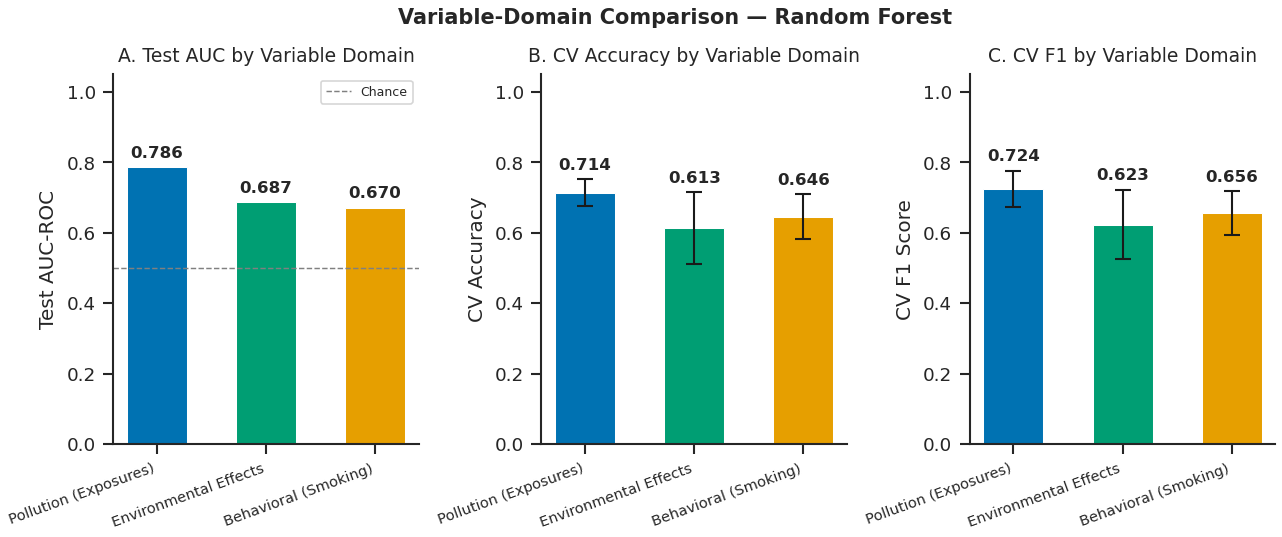

In [30]:
# ── Helper: parse "0.772 ± 0.023" → (mean, std) ────────────────────────────
def parse_mean_std(s):
    """Extract (mean, std) from a string like '0.772 ± 0.023'."""
    parts = str(s).split("±")
    return float(parts[0].strip()), float(parts[1].strip()) if len(parts) == 2 else 0.0

# ── Figure: Domain Comparison — 3 Panels ────────────────────────────────────
if len(comp_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.2), gridspec_kw={"wspace": 0.40})
    domain_labels = comp_df["Domain"].tolist()
    x = np.arange(len(domain_labels))
    bar_colors = [OI["blue"], OI["green"], OI["orange"]][:len(domain_labels)]
    bar_w = 0.55

    # ── Parse CV columns ────────────────────────────────────────────────────
    auc_mean = comp_df["CV_AUC"].apply(lambda s: parse_mean_std(s)[0]).values
    auc_std  = comp_df["CV_AUC"].apply(lambda s: parse_mean_std(s)[1]).values
    acc_mean = comp_df["CV_ACC"].apply(lambda s: parse_mean_std(s)[0]).values
    acc_std  = comp_df["CV_ACC"].apply(lambda s: parse_mean_std(s)[1]).values
    f1_mean  = comp_df["CV_F1"].apply(lambda s: parse_mean_std(s)[0]).values
    f1_std   = comp_df["CV_F1"].apply(lambda s: parse_mean_std(s)[1]).values

    # ── Panel A: Test AUC ───────────────────────────────────────────────────
    ax = axes[0]
    bars = ax.bar(x, comp_df["Test_AUC"].values, width=bar_w,
                  color=bar_colors, edgecolor="white", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(domain_labels, fontsize=7, rotation=20, ha="right")
    ax.set_ylabel("Test AUC-ROC")
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="grey", ls="--", lw=0.7, label="Chance")
    for bar, val in zip(bars, comp_df["Test_AUC"].values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title("A. Test AUC by Variable Domain", fontsize=9)
    ax.legend(fontsize=6, loc="upper right")

    # ── Panel B: CV Accuracy ± SD ───────────────────────────────────────────
    ax = axes[1]
    bars = ax.bar(x, acc_mean, yerr=acc_std, width=bar_w,
                  color=bar_colors, edgecolor="white", linewidth=0.5,
                  capsize=4, error_kw={"lw": 1.0, "capthick": 1.0})
    ax.set_xticks(x)
    ax.set_xticklabels(domain_labels, fontsize=7, rotation=20, ha="right")
    ax.set_ylabel("CV Accuracy")
    ax.set_ylim(0, 1.05)
    for bar, m, s in zip(bars, acc_mean, acc_std):
        ax.text(bar.get_x() + bar.get_width() / 2, m + s + 0.02,
                f"{m:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title("B. CV Accuracy by Variable Domain", fontsize=9)

    # ── Panel C: CV F1 ± SD ─────────────────────────────────────────────────
    ax = axes[2]
    bars = ax.bar(x, f1_mean, yerr=f1_std, width=bar_w,
                  color=bar_colors, edgecolor="white", linewidth=0.5,
                  capsize=4, error_kw={"lw": 1.0, "capthick": 1.0})
    ax.set_xticks(x)
    ax.set_xticklabels(domain_labels, fontsize=7, rotation=20, ha="right")
    ax.set_ylabel("CV F1 Score")
    ax.set_ylim(0, 1.05)
    for bar, m, s in zip(bars, f1_mean, f1_std):
        ax.text(bar.get_x() + bar.get_width() / 2, m + s + 0.02,
                f"{m:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title("C. CV F1 by Variable Domain", fontsize=9)

    fig.suptitle(f"Variable-Domain Comparison — {best_name}", fontsize=10, y=1.02, fontweight='bold')
    fig.tight_layout()
    savefig(fig, "fig_domain_comparison")
    plt.show()
else:
    print("No domains had available variables — skipping figure.")

---

## Summary of All Outputs

The cell below lists all tables, figures, and supplementary files saved to
the `publication_outputs/` directory during this pipeline run. These files
are intended for direct inclusion in the manuscript or supplementary
materials.

In [ ]:
import glob

files = sorted(glob.glob(os.path.join(OUTDIR, "*")))
print(f"\nAll output files ({len(files)})")
for f in files:
    size_kb = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):55s}  ({size_kb:.1f} KB)")
print(f"\nOutput directory: {os.path.abspath(OUTDIR)}")
print("Pipeline complete.")

### Export Outputs as ZIP Archive

For convenience, all output files are compressed into a single ZIP archive
for download or transfer.

In [ ]:
import shutil

source_dir = os.path.abspath(OUTDIR)
output_zip_name = "publication_outputs_archive"
shutil.make_archive(output_zip_name, "zip", source_dir)
print(f"Folder '{source_dir}' successfully zipped into '{output_zip_name}.zip'")